In [3]:
from geopy.distance import geodesic


In [4]:
import pandas as pd

file_path = "dataset/1742574481558_Dataset-ME-2025.xlsx"  # ganti dengan path ke file kamu
xls = pd.ExcelFile(file_path)
print(xls.sheet_names)


['Customer Final', 'DC Final', 'Final', 'Vehicle Details', 'Container Details', 'Customer Code', 'DC', 'Port', 'Land Logistics', 'Ocean Freight', 'Truck by STP (LTA)', 'Resources', 'STP Performance', 'Spending (Topline)', 'T&W Cost', 'ODS Cost', 'Population', 'Dist Center', 'Middle Mile']


In [5]:


# --- 1. DC Sheet: Tampilkan Area dan jumlah baris per Area ---
df_dc = pd.read_excel(xls, sheet_name="DC")
area_counts = df_dc['Area'].value_counts().reset_index()
area_counts.columns = ['Area', 'Jumlah Baris']
# print("Jumlah baris per Area di sheet 'DC':")
# print(area_counts)


In [6]:
df_dc.columns

Index(['Area', 'DC ID', 'Distributor', 'Distributor Area', 'Area.1', 'Type',
       'Sent From', 'Address', 'Latitude', 'Longitude',
       'Monthly Demand (Average FY2021) - Carton',
       'Max Demand - FY2021 - Carton', 'Fixed Operating Costs'],
      dtype='object')

In [7]:
import pandas as pd

# --- DC Sheet ---
df_dc = pd.read_excel(xls, sheet_name="DC Final")
area_set = set(df_dc['Area'].dropna().unique())

# --- Middle Mile Sheet ---
df_middle = pd.read_excel(xls, sheet_name="Resources", header=3)
origin_area_set = set(df_middle['BRANCH'].dropna().unique())

# --- Bandingkan ---
same_areas = area_set & origin_area_set  # irisan = yang sama
only_in_dc = area_set - origin_area_set
only_in_middle = origin_area_set - area_set

# --- Print Areas ---
print("✅ Area yang ADA di keduanya:")
print(sorted(same_areas))

print("\n📌 Area yang HANYA ADA di sheet 'DC Final':")
print(sorted(only_in_dc))

# --- Show count of each Type for areas only in DC Final ---
only_in_dc_df = df_dc[df_dc['Area'].isin(only_in_dc)]
type_counts = only_in_dc_df['Type'].value_counts()

print("\n📌 Jumlah setiap Type pada area yang hanya ada di sheet 'DC Final':")
print(type_counts)

print("\n📌 Area yang HANYA ADA di sheet 'resources':")
print(sorted(only_in_middle))

only_in_dc_df = df_dc[df_dc['Area'].isin(only_in_dc)]
filtered_areas = only_in_dc_df[only_in_dc_df['Type'] != 'Depo'][['Area', 'Type']]

print("\n📌 Area yang HANYA ADA di sheet 'DC Final' dan Type-nya bukan 'Depo':")
print(filtered_areas)


✅ Area yang ADA di keduanya:
['Balikpapan', 'Banjarmasin', 'Bau-Bau', 'Berau', 'Bone', 'Gorontalo', 'Kendari', 'Kupang', 'Lombok', 'Luwuk', 'Makassar', 'Mamuju', 'Manado', 'Maumere', 'Palangkaraya', 'Palopo', 'Palu', 'Poso', 'Samarinda', 'Sampit', 'Sumbawa', 'Tarakan']

📌 Area yang HANYA ADA di sheet 'DC Final':
['Ampah - Teweh ', 'Amurang', 'BIMA', 'Barabai', 'Barru', 'Batulicin', 'Belopa', 'Bitung', 'Bontang', 'Bontang-Sangata', 'Bulukumba', 'Denpasar', 'Gowa', 'Jeneponto', 'Ketapang', 'Kolaka', 'Kotamobagu', 'Mangkutana', 'Marisa', 'Pangkalanbun ', 'Pangkep', 'Pare-Pare', 'Parigi', 'Penajam-Grogot', 'Polman', 'Pontianak', 'Rantau', 'Sengkang', 'Singkawang', 'Sinjai', 'Sintang', 'Takalar', 'Tomohon', 'Toraja', 'Unaaha']

📌 Jumlah setiap Type pada area yang hanya ada di sheet 'DC Final':
Type
Depo           30
Direct DC       2
Indirect DC     2
Direct CPU      1
Name: count, dtype: int64

📌 Area yang HANYA ADA di sheet 'resources':
['Bali', 'Bima', 'Pare-pare']

📌 Area yang HANYA ADA

In [8]:
import pandas as pd

# Load dari Excel
xls = pd.ExcelFile("dataset/1742574481558_Dataset-ME-2025.xlsx")
df_dc = pd.read_excel(xls, sheet_name="DC Final")

# --- Bersihkan dan Standarisasi Kolom ---
df_dc.columns = df_dc.columns.str.strip().str.lower().str.replace(" ", "_")

# --- Ambil Kolom Penting ---
df_node = df_dc[[
    'dc_id',           # node_id
    'type',            # node_type
    'area',            # lokasi spesifik node
    'distributor_area',# regional / cakupan
    'latitude',
    'longitude',
    'sent_from'
]].dropna(subset=['dc_id', 'latitude', 'longitude'])

# --- Rename agar sesuai format standar node ---
df_node = df_node.rename(columns={
    'dc_id': 'node_id',
    'type': 'node_type',
    'area': 'location_name',
    'distributor_area': 'region'
})


# --- Pastikan koordinat dalam format float ---
df_node['latitude'] = df_node['latitude'].astype(str).str.replace(',', '.').astype(float)
df_node['longitude'] = df_node['longitude'].astype(str).str.replace(',', '.').astype(float)

# --- (Opsional) Drop duplikat ---
df_node = df_node.drop_duplicates(subset='node_id')

# --- Lihat hasil ---
print(df_node.head())


  node_id node_type   location_name      region  latitude   longitude  \
0   DC001      Depo  Ampah - Teweh   Kalimantan -0.935414  114.901123   
1   DC002      Depo         Amurang   BCP Outer  1.255330  124.631870   
2   DC003      Depo         Barabai  Kalimantan -2.581936  115.390569   
3   DC004      Depo           Barru   BCP Outer -4.405620  119.618770   
4   DC005      Depo       Batulicin  Kalimantan -3.455801  115.997490   

   sent_from  
0        NaN  
1     Manado  
2        NaN  
3  Pare-Pare  
4        NaN  


In [9]:
# Koordinat umum Karawang (bisa disesuaikan)
karawang_lat = -6.305384
karawang_lon = 107.296913

# Tambahkan SDC ke df_node
df_node = pd.concat([
    df_node,
    pd.DataFrame([{
        'node_id': 'SDC',
        'node_type': 'Pabrik',
        'location_name': 'Karawang',
        'region': 'Jawa Barat',
        'latitude': karawang_lat,
        'longitude': karawang_lon,
        'sent_from': None
    }])
], ignore_index=True)


In [10]:
df_edge = df_node[df_node['sent_from'].notna()].copy()

# Buat kolom edge_from dan edge_to
df_edge['edge_from'] = df_edge['sent_from']
df_edge['edge_to'] = df_edge['location_name']

# Sekalian ambil ID node yang sesuai
df_edge = df_edge.merge(df_node[['location_name', 'node_id']], how='left', left_on='edge_from', right_on='location_name', suffixes=('', '_from'))
df_edge = df_edge.merge(df_node[['location_name', 'node_id']], how='left', left_on='edge_to', right_on='location_name', suffixes=('', '_to'))

# Bersihin kolom
df_edges_clean = df_edge[[
    'node_id_from', 'node_id_to'
]].rename(columns={
    'node_id_from': 'from_node',
    'node_id_to': 'to_node'
})


In [11]:
import networkx as nx

# Inisialisasi graf terarah
G = nx.DiGraph()

# Tambahkan node
for _, row in df_node.iterrows():
    G.add_node(row['node_id'], 
               location=row['location_name'],
               type=row['node_type'],
               latitude=row['latitude'],
               longitude=row['longitude'])

# Tambahkan edge dari df_edges_clean
for _, row in df_edges_clean.iterrows():
    G.add_edge(row['from_node'], row['to_node'])

G.add_node(
    'SDC',
    label='SDC',
    type='Pabrik',
    pos=(karawang_lon, karawang_lat)
)



C:\Users\Bara\AppData\Local\Temp\ipykernel_31048\2417704153.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


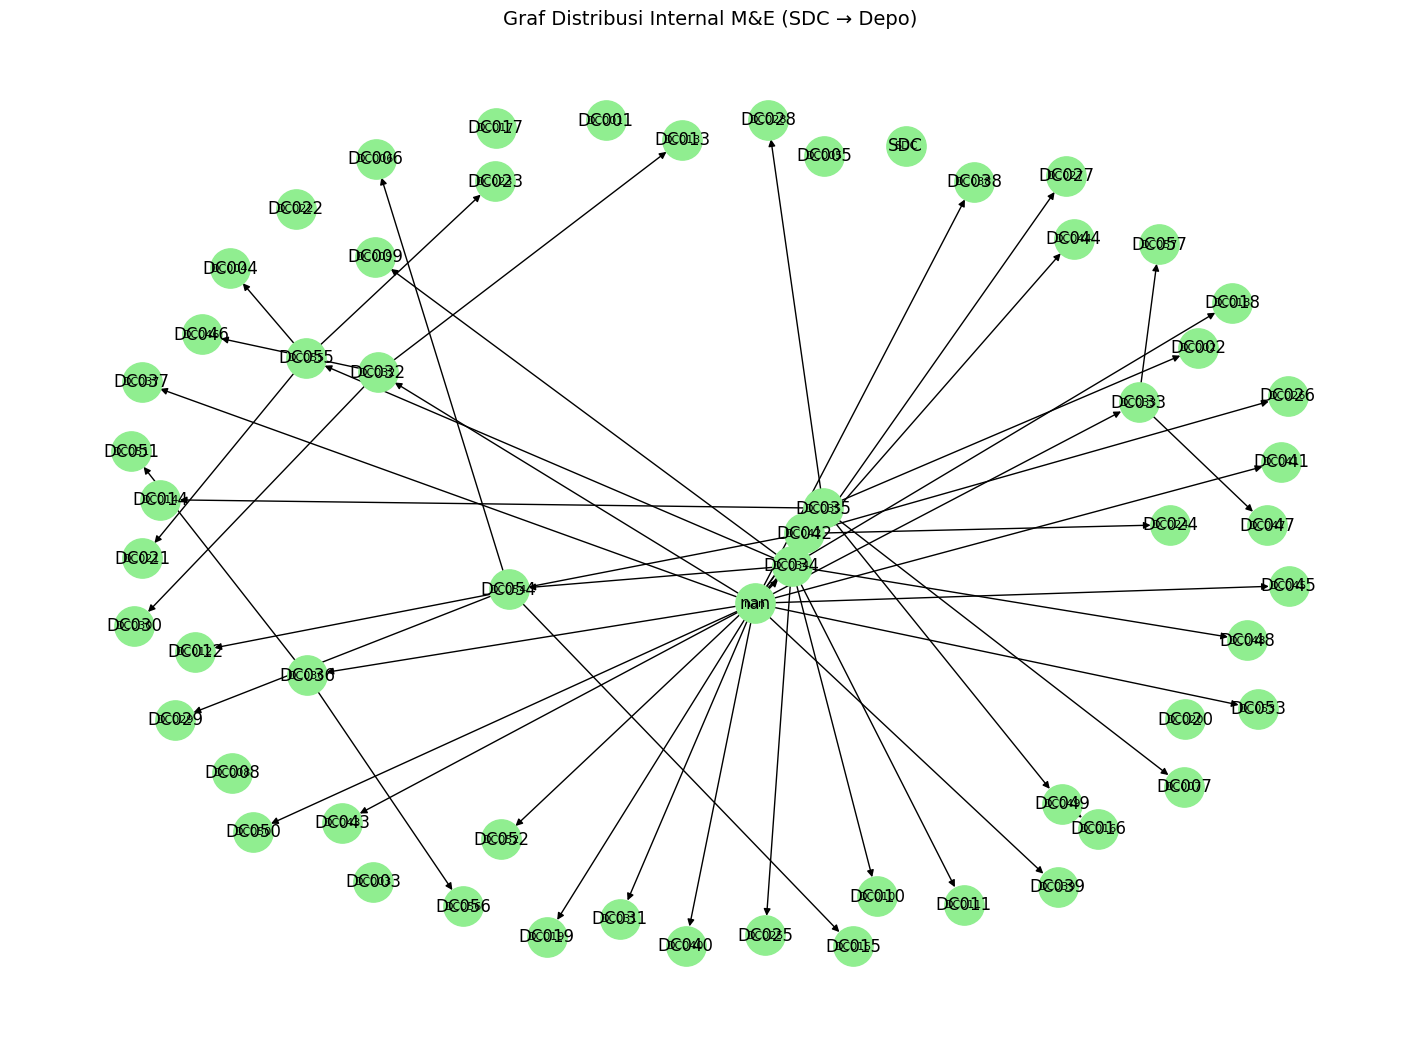

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=800, arrows=True)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Graf Distribusi Internal M&E (SDC → Depo)", fontsize=14)
plt.tight_layout()
plt.show()


In [13]:
# Buat dict posisi berdasarkan lat-long
pos_geo = {
    row['node_id']: (row['longitude'], row['latitude'])  # format: (x, y) = (lon, lat)
    for _, row in df_node.iterrows()
}


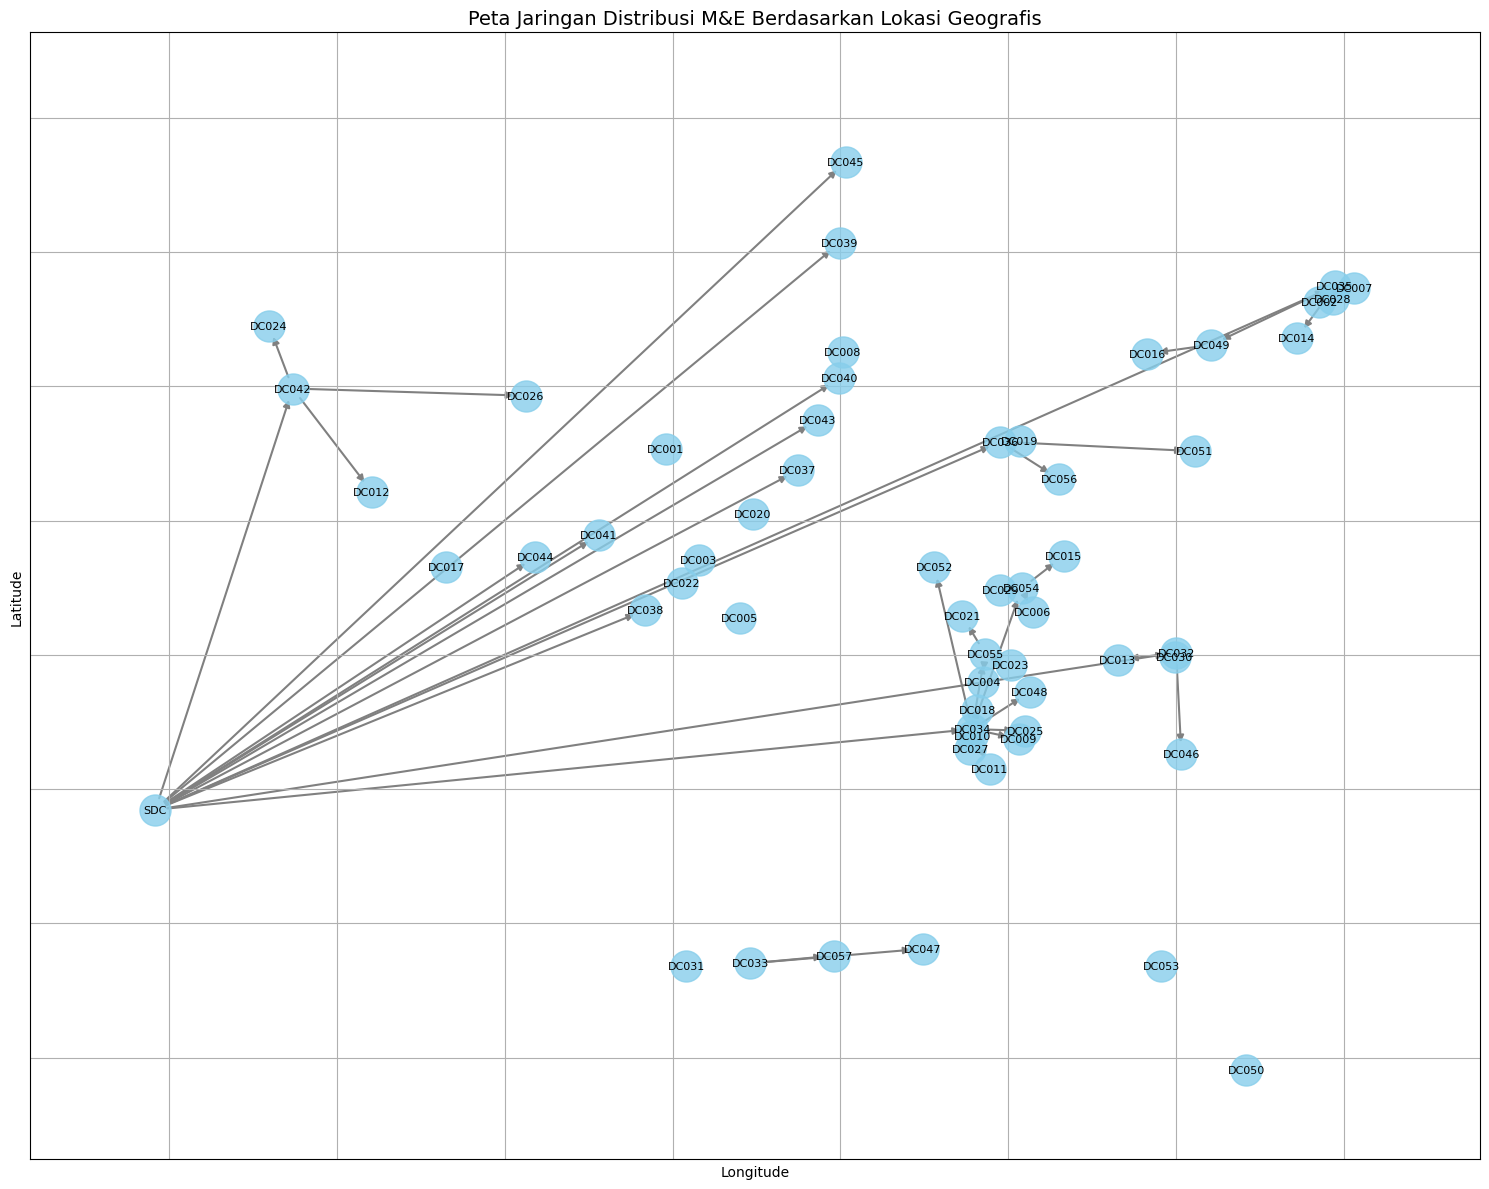

In [14]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# --- STEP 1: Load Dataset ---
xls = pd.ExcelFile("dataset/1742574481558_Dataset-ME-2025.xlsx")
df_dc = pd.read_excel(xls, sheet_name="DC Final")

# --- STEP 2: Preprocessing df_node (semua DC) ---
df_dc.columns = df_dc.columns.str.strip().str.lower().str.replace(" ", "_")

df_node = df_dc[[
    'dc_id', 'type', 'area', 'distributor_area', 'latitude', 'longitude', 'sent_from'
]].dropna(subset=['dc_id', 'latitude', 'longitude'])

df_node = df_node.rename(columns={
    'dc_id': 'node_id',
    'type': 'node_type',
    'area': 'location_name',
    'distributor_area': 'region'
})

# Pastikan latitude & longitude numerik
df_node['latitude'] = df_node['latitude'].astype(str).str.replace(',', '.').astype(float)
df_node['longitude'] = df_node['longitude'].astype(str).str.replace(',', '.').astype(float)

# --- STEP 3: Bangun Graph G ---
G = nx.DiGraph()

# Tambah node
for _, row in df_node.iterrows():
    G.add_node(
        row['node_id'],
        label=row['node_id'],
        type=row['node_type'],
        pos=(row['longitude'], row['latitude'])
    )

# --- Tambahkan node SDC Karawang secara manual ---
karawang_lat = -6.305384
karawang_lon = 107.296913

G.add_node(
    'SDC',
    label='SDC',
    type='Pabrik',
    pos=(karawang_lon, karawang_lat)
)

# --- STEP 4: Buat Dataframe Edge dari sent_from ---
# Map lokasi asal (sent_from) → node_id
location_to_node = dict(zip(df_node['location_name'], df_node['node_id']))

df_edges = df_node[df_node['sent_from'].notna()][['node_id', 'sent_from']].copy()
df_edges = df_edges.rename(columns={'node_id': 'to_node', 'sent_from': 'from_node'})
df_edges['from_node'] = df_edges['from_node'].map(location_to_node)

# Drop baris yang mapping-nya gagal
df_edges = df_edges.dropna(subset=['from_node'])

# Tambah edge ke graf
for _, row in df_edges.iterrows():
    G.add_edge(row['from_node'], row['to_node'])

# Tambahkan edge dari Karawang ke node yang sent_from-nya 'SDC'
karawang_children = df_node[df_node['sent_from'] == 'SDC']['node_id'].tolist()

for to_node in karawang_children:
    G.add_edge('SDC', to_node)


# --- STEP 5: Gambar Peta Jaringan Distribusi ---
pos_geo = {node: data['pos'] for node, data in G.nodes(data=True)}

plt.figure(figsize=(15, 12))

# Gambar node
nx.draw_networkx_nodes(
    G, pos_geo, 
    node_color='skyblue', 
    node_size=500, 
    alpha=0.8
)

# Gambar edge (panah antar DC)
nx.draw_networkx_edges(
    G, pos_geo, 
    edge_color='gray', 
    arrows=True,
    width=1.5
)

# Tambahkan label node
labels = {node: G.nodes[node]['label'] for node in G.nodes}
nx.draw_networkx_labels(
    G, pos_geo, labels,
    font_size=8
)

plt.title("Peta Jaringan Distribusi M&E Berdasarkan Lokasi Geografis", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.axis('equal')  # supaya bentuk geografis tidak melebar
plt.tight_layout()
plt.show()


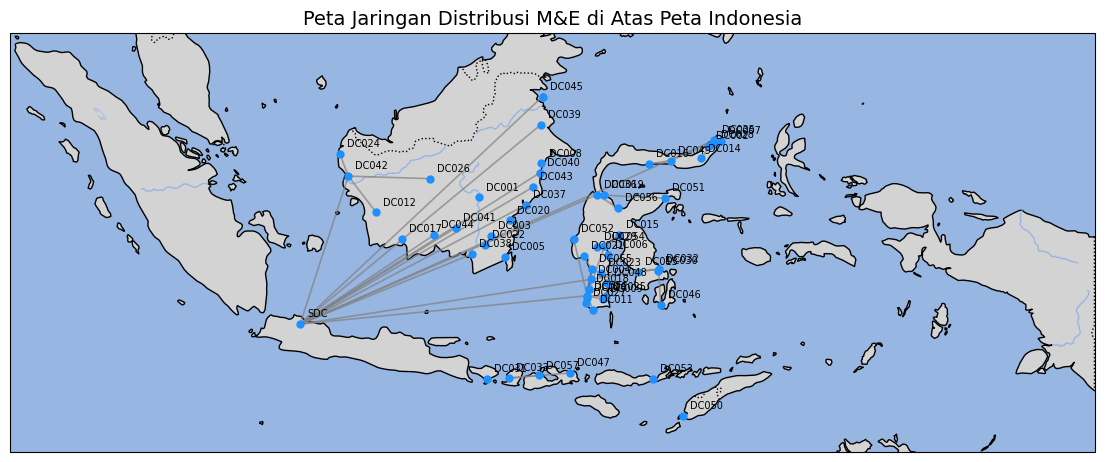

In [15]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import networkx as nx

# Ambil posisi node
pos_geo = {node: (data['pos'][0], data['pos'][1]) for node, data in G.nodes(data=True)}  # (lon, lat)

# Setup peta dengan Cartopy
fig = plt.figure(figsize=(14, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([95, 141, -11, 6])  # Indonesia bbox: [lon_min, lon_max, lat_min, lat_max]

# Tambah fitur geografi
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# Gambar edges
for u, v in G.edges():
    x_vals = [pos_geo[u][0], pos_geo[v][0]]
    y_vals = [pos_geo[u][1], pos_geo[v][1]]
    ax.plot(x_vals, y_vals, color='gray', linewidth=1.2, alpha=0.7, transform=ccrs.Geodetic())

# Gambar nodes
for node, (lon, lat) in pos_geo.items():
    ax.plot(lon, lat, marker='o', color='dodgerblue', markersize=5, transform=ccrs.PlateCarree())
    ax.text(lon + 0.3, lat + 0.3, G.nodes[node]['label'], fontsize=7, transform=ccrs.PlateCarree())

# Judul dan label
plt.title("Peta Jaringan Distribusi M&E di Atas Peta Indonesia", fontsize=14)
plt.show()


In [16]:
# Tambah SDC (jika belum)
karawang_lat = -6.305384
karawang_lon = 107.296913

df_node = pd.concat([
    df_node,
    pd.DataFrame([{
        'node_id': 'SDC',
        'node_type': 'Pabrik',
        'location_name': 'Karawang',
        'region': 'Jawa Barat',
        'latitude': karawang_lat,
        'longitude': karawang_lon,
        'sent_from': None
    }])
], ignore_index=True)

df_node = df_node.drop_duplicates(subset='node_id', keep='last')



In [17]:
from geopy.distance import geodesic
import pandas as pd

# Ambil koordinat dan ID node
locations = list(zip(df_node['latitude'], df_node['longitude']))
node_ids = df_node['node_id'].tolist()

# Buat DataFrame kosong
distance_matrix = pd.DataFrame(index=node_ids, columns=node_ids)

# Hitung jarak (km) antar semua node
for i in range(len(locations)):
    for j in range(len(locations)):
        distance = geodesic(locations[i], locations[j]).km
        distance_matrix.iloc[i, j] = round(distance, 2)

# Tampilkan sebagian hasil
print("Distance matrix antar DC (termasuk SDC/Karawang):")
print(distance_matrix.head())


Distance matrix antar DC (termasuk SDC/Karawang):
         DC001    DC002    DC003   DC004    DC005   DC006    DC007   DC008  \
DC001      0.0  1109.91   190.03   649.9   304.21  664.35  1171.76  333.47   
DC002  1109.91      0.0  1112.56  838.32  1092.87   697.3    62.72  794.53   
DC003   190.03  1112.56      0.0  511.24   117.85  559.66  1175.29  416.42   
DC004    649.9   838.32   511.24     0.0   415.66  141.98   895.12  590.59   
DC005   304.21  1092.87   117.85  415.66      0.0  485.39  1155.26  470.19   

        DC009   DC010  ...   DC049    DC050   DC051   DC052    DC053   DC054  \
DC001  754.43  692.84  ...  920.38  1400.48  877.13  485.13  1180.74   632.7   
DC002  874.75  916.83  ...  192.29  1270.27   320.4  772.77  1124.91  681.94   
DC003  606.22  537.36  ...  920.31  1232.72  841.57  390.28  1014.96   537.1   
DC004  111.08   90.07  ...  672.49   772.05  518.13  206.15   552.78  167.73   
DC005  502.73  430.64  ...  902.36   1117.6   803.3  333.49    900.8   470.0   



In [18]:
df_land = pd.read_excel(xls, sheet_name="Land Logistics")
df_land.columns = df_land.columns.str.strip().str.lower().str.replace(" ", "_")

df_land['fixed_cost'] = (
    df_land['fixed_cost'].astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df_land_edges = df_land[[
    'dc_id', 'destination_(city)', 'type', 'volume', 'fixed_cost'
]].rename(columns={
    'dc_id': 'from_dc',
    'destination_(city)': 'to_area',
    'type': 'mode',
    'volume': 'volume_cbm',
    'fixed_cost': 'cost_idr'
})

df_land_edges.head()

,from_dc,to_area,mode,volume_cbm,cost_idr
0,DC031,Denpasar,Build Up (40 CBM),1600,12500000.0
1,DC031,Denpasar,FUSO (22 CBM),880,8682800.0
2,DC033,Lombok,Build Up (40 CBM),1600,23500000.0
3,DC033,Lombok,CDD (7 CBM),280,13000000.0
4,DC033,Lombok,FUSO (22 CBM),880,17500000.0


In [19]:
df_ocean = pd.read_excel(
    xls, 
    sheet_name="Ocean Freight",
    dtype=str  # ⬅️ ini penting: baca semua kolom sebagai string!
)
print(df_ocean.columns.tolist())
df_ocean.head()



df_ocean['fixed_cost_clean'] = pd.to_numeric(df_ocean['Fixed Cost'], errors='coerce').fillna(0).round(0)
df_ocean.head()

['DC ID', 'Carrier Provider', 'Fixed Cost', 'Variable Cost', 'Destination (City)', 'Customer Code', 'Customer Name', 'Type', 'Volume']


,DC ID,Carrier Provider,Fixed Cost,Variable Cost,Destination (City),Customer Code,Customer Name,Type,Volume,fixed_cost_clean
0,DC037,TPIL,11214768.649789028,NaN,Balikpapan,2000277545,LTA Balikpapan,20FT,1160,11214769.0
1,DC037,TPIL,19584836.89873419,NaN,Balikpapan,2000277545,LTA Balikpapan,40FT,2360,19584837.0
2,DC038,TPIL,10071150.253164558,NaN,Banjarmasin,2000277543,LTA Banjarmasin,20FT,1160,10071150.0
3,DC038,TPIL,15535291.10970464,NaN,Banjarmasin,2000277543,LTA Banjarmasin,40FT,2360,15535291.0
4,DC039,TPIL,17082458.143459916,NaN,Berau,2002767095,LTA Berau,20FT,1160,17082458.0


In [20]:
df_ocean_clean = df_ocean[[
    'DC ID', 'Destination (City)', 'Type', 'Volume', 'fixed_cost_clean'
]].rename(columns={
    'DC ID': 'from_dc',
    'Destination (City)': 'to_area',
    'Type': 'mode',
    'Volume': 'volume_cbm',
    'fixed_cost_clean': 'cost_idr'
})

print(df_ocean_clean[['from_dc', 'to_area', 'mode', 'cost_idr']].sample(5))


   from_dc    to_area  mode    cost_idr
20   DC044     Sampit  20FT  15536568.0
8    DC034   Makassar  20FT  10300000.0
15   DC036       Palu  40FT  17250000.0
18   DC043  Samarinda  20FT  11954915.0
17   DC042  Pontianak  40FT  17943460.0


In [21]:
df_edges = pd.concat([df_land_edges, df_ocean_clean], ignore_index=True)


In [22]:
print("Jumlah total rute:", len(df_edges))
print(df_edges.sample(5))  # contoh acak

# Optional: Simpan ke file
# df_edges.to_excel("all_edges_logistik.xlsx", index=False)


Jumlah total rute: 29
   from_dc     to_area               mode volume_cbm    cost_idr
4    DC033      Lombok      FUSO (22 CBM)        880  17500000.0
11   DC032     Kendari               20FT       1160  17200000.0
6    DC037  Balikpapan               40FT       2360  19584837.0
21   DC042   Pontianak               20FT       1160  11365344.0
0    DC031    Denpasar  Build Up (40 CBM)       1600  12500000.0


In [23]:
def classify_mode(mode_str):
    if pd.isna(mode_str):
        return 'Unknown'
    mode_str = str(mode_str).upper()
    if 'FT' in mode_str:
        return 'Ocean'
    return 'Land'

df_edges['mode_type'] = df_edges['mode'].apply(classify_mode)
df_edges.sample(5)



,from_dc,to_area,mode,volume_cbm,cost_idr,mode_type
9,DC039,Berau,20FT,1160,17082458.0,Ocean
26,DC044,Sampit,40FT,2360,26680606.0,Ocean
12,DC032,Kendari,40FT,2360,27500000.0,Ocean
21,DC042,Pontianak,20FT,1160,11365344.0,Ocean
17,DC041,Palangkaraya,20FT,1160,13705881.0,Ocean


In [24]:
df_dc_edges_joined = df_node.merge(
    df_edges,
    left_on='node_id',
    right_on='from_dc',
    how='left'
)

df_summary_per_dc = (
    df_dc_edges_joined
    .groupby('node_id')[['cost_idr', 'volume_cbm']]
    .sum()
    .reset_index()
    .rename(columns={
        'cost_idr': 'total_rate_from_node',
        'volume_cbm': 'total_volume_from_node'
    })
)

mode_per_dc = (
    df_edges
    .groupby('from_dc')['mode']
    .agg(lambda x: ', '.join(sorted(set(x))))
    .reset_index()
    .rename(columns={'from_dc': 'node_id', 'mode': 'modes'})
)

# Gabungkan ke df_summary_per_dc
df_dc_summary_with_mode = df_summary_per_dc.merge(mode_per_dc, on='node_id', how='left')

# Gabungkan ke df_node (biar satu row per DC)
df_dc_final_summary = df_node.merge(df_dc_summary_with_mode, on='node_id', how='left')

# Lihat hasil untuk DC031
df_dc_final_summary[df_dc_final_summary['node_id'] == 'DC031']




,node_id,node_type,location_name,region,latitude,longitude,sent_from,total_rate_from_node,total_volume_from_node,modes
30,DC031,Direct CPU,Denpasar,BCP Outer,-8.63955,115.20248,SDC (CPU),21182800.0,2480,"Build Up (40 CBM), FUSO (22 CBM)"


In [25]:
print(df_edges.columns)


Index(['from_dc', 'to_area', 'mode', 'volume_cbm', 'cost_idr', 'mode_type'], dtype='object')


In [26]:
df_dc_final_summary.sample(10)

,node_id,node_type,location_name,region,latitude,longitude,sent_from,total_rate_from_node,total_volume_from_node,modes
56,DC057,Indirect DC,Sumbawa,BCP Outer,-8.478560,117.407170,Lombok,0.0,0,NaN
22,DC023,Depo,Sengkang,BCP Outer,-4.143560,120.039140,Pare-Pare,0.0,0,NaN
14,DC015,Depo,Mangkutana,BCP Outer,-2.525350,120.824050,Palopo,0.0,0,NaN
15,DC016,Depo,Marisa,BCP Outer,0.486710,122.070340,Gorontalo,0.0,0,NaN
33,DC034,Direct CPU,Makassar,BCP Outer,-5.104040,119.462980,SDC,25300000.0,11602360,"20FT, 40FT"
31,DC032,Direct CPU,Kendari,BCP Outer,-3.965130,122.501270,SDC,44700000.0,11602360,"20FT, 40FT"
38,DC039,Direct DC,Berau,Kalimantan,2.138839,117.492022,SDC,17082458.0,1160,20FT
44,DC045,Direct DC,Tarakan,Kalimantan,3.343070,117.576925,SDC,48891732.0,11602360,"20FT, 40FT"
40,DC041,Direct DC,Palangkaraya,Kalimantan,-2.218321,113.900455,SDC,36245730.0,11602360,"20FT, 40FT"
0,DC001,Depo,Ampah - Teweh,Kalimantan,-0.935414,114.901123,NaN,0.0,0,NaN


In [27]:
# Merge df_node dengan df_edges
df_dc_olCost = df_node.merge(
    df_edges,
    left_on='node_id',
    right_on='from_dc',
    how='left'
)

# Drop kolom 'from_dc' dan 'to_area' dari hasil merge
df_dc_olCost = df_dc_olCost.drop(columns=['from_dc', 'to_area'])

# Cek hasil
df_dc_olCost.sample(10)



,node_id,node_type,location_name,region,latitude,longitude,sent_from,mode,volume_cbm,cost_idr,mode_type
60,DC047,Indirect DC,BIMA,BCP Outer,-8.377590,118.725640,Lombok,NaN,NaN,NaN,NaN
51,DC042,Direct DC,Pontianak,Kalimantan,-0.031090,109.342500,SDC,20FT,1160,11365344.0,Ocean
3,DC004,Depo,Barru,BCP Outer,-4.405620,119.618770,Pare-Pare,NaN,NaN,NaN,NaN
25,DC026,Depo,Sintang,Kalimantan,-0.137800,112.810600,Pontianak,NaN,NaN,NaN,NaN
1,DC002,Depo,Amurang,BCP Outer,1.255330,124.631870,Manado,NaN,NaN,NaN,NaN
16,DC017,Depo,Pangkalanbun,Kalimantan,-2.684718,111.631067,NaN,NaN,NaN,NaN,NaN
37,DC034,Direct CPU,Makassar,BCP Outer,-5.104040,119.462980,SDC,20FT,1160,10300000.0,Ocean
64,DC051,Indirect DC,Luwuk,BCP Outer,-0.964240,122.781530,Palu,NaN,NaN,NaN,NaN
9,DC010,Depo,Gowa,BCP Outer,-5.205140,119.463740,Makassar,NaN,NaN,NaN,NaN
42,DC036,Direct CPU,Palu,BCP Outer,-0.823200,119.885150,SDC,40FT,2360,17250000.0,Ocean


In [28]:
# Ambil data dari sheet rute (misal: df_sdc_routing)
df_sdc_routing = df_dc_olCost.copy()

# Filter hanya node_type: Direct DC atau Direct CPU
df_sdc_direct = df_sdc_routing[df_sdc_routing['node_type'].isin(['Direct DC', 'Direct CPU'])].copy()

# Filter hanya rute dari SDC
df_sdc_direct = df_sdc_direct[df_sdc_direct['sent_from'].str.contains("SDC", case=False, na=False)]

# Cek hasil akhir
print(df_sdc_direct[['node_id', 'location_name', 'sent_from', 'mode', 'cost_idr']].head())


   node_id location_name  sent_from               mode    cost_idr
30   DC031      Denpasar  SDC (CPU)  Build Up (40 CBM)  12500000.0
31   DC031      Denpasar  SDC (CPU)      FUSO (22 CBM)   8682800.0
32   DC032       Kendari        SDC               20FT  17200000.0
33   DC032       Kendari        SDC               40FT  27500000.0
34   DC033        Lombok  SDC (CPU)  Build Up (40 CBM)  23500000.0


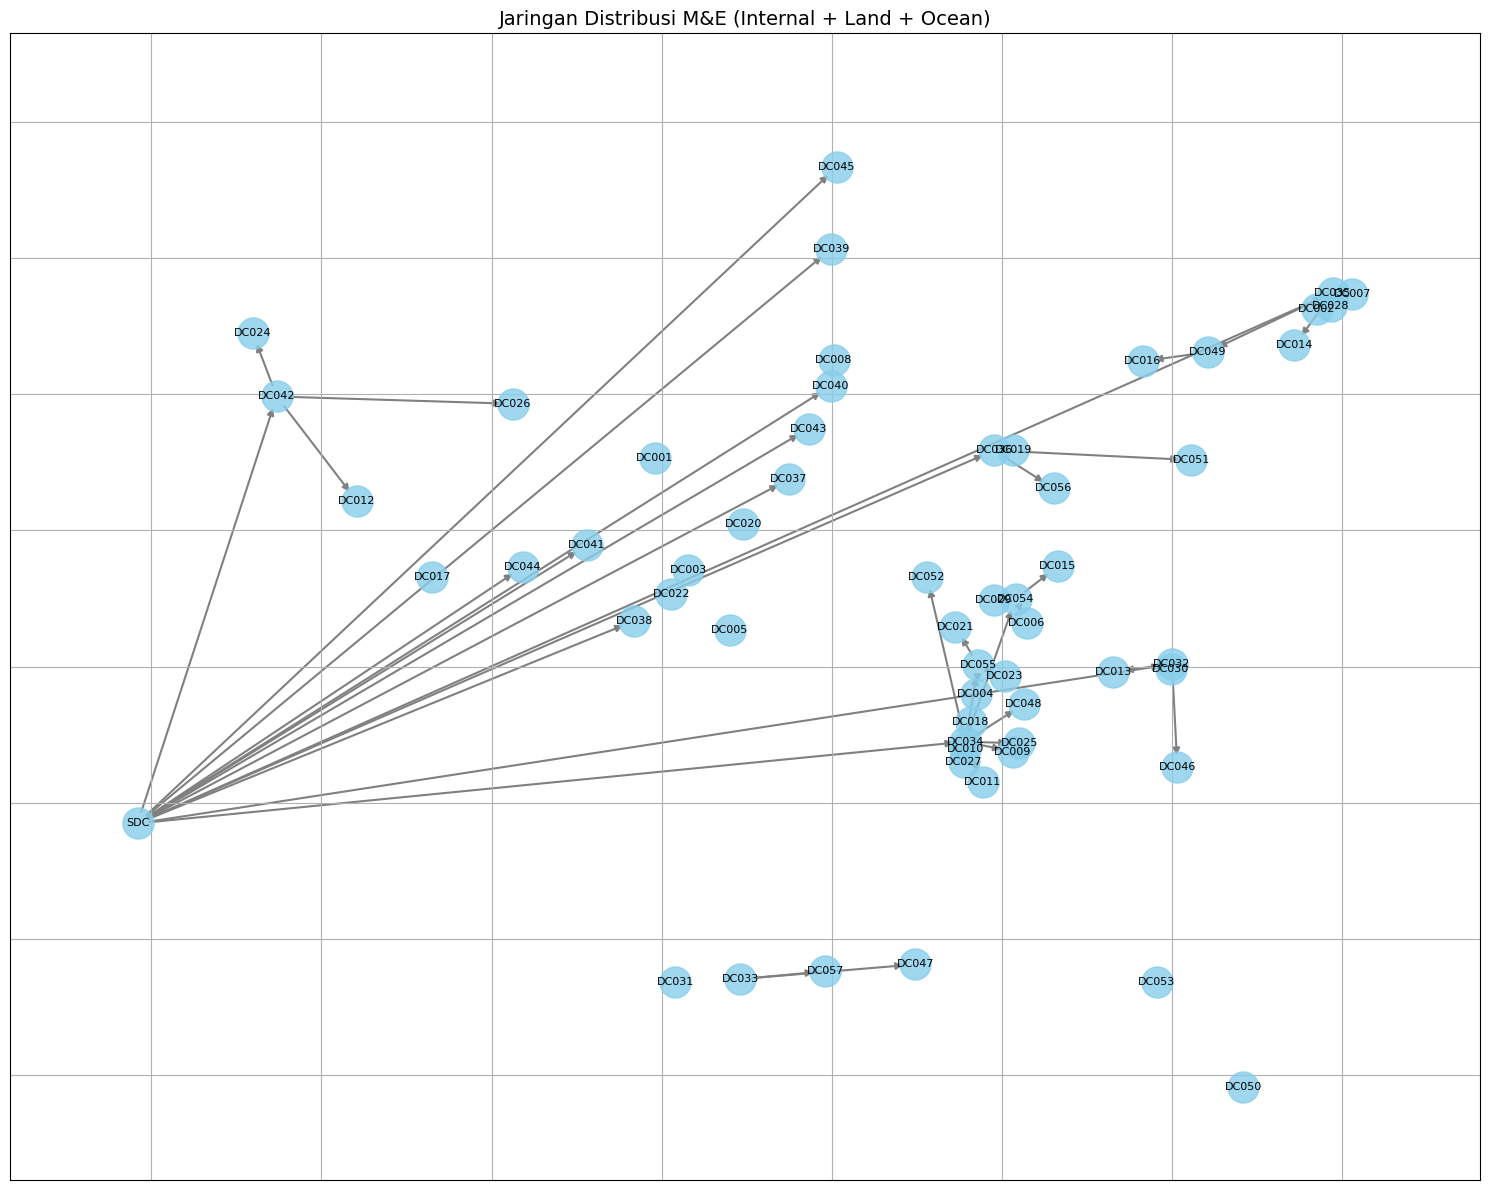

In [29]:
# Pisahkan edge berdasarkan mode_type
land_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('mode_type') == 'Land']
ocean_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('mode_type') == 'Ocean']
internal_edges = [(u, v) for u, v in G.edges if 'mode_type' not in G[u][v]]

plt.figure(figsize=(15, 12))
nx.draw_networkx_nodes(G, pos_geo, node_color='skyblue', node_size=500, alpha=0.8)

nx.draw_networkx_edges(G, pos_geo, edgelist=internal_edges, edge_color='gray', arrows=True, width=1.5)
nx.draw_networkx_edges(G, pos_geo, edgelist=land_edges, edge_color='green', arrows=True, width=2)
nx.draw_networkx_edges(G, pos_geo, edgelist=ocean_edges, edge_color='blue', style='dashed', arrows=True, width=2)

nx.draw_networkx_labels(G, pos_geo, labels={n: G.nodes[n]['label'] for n in G.nodes}, font_size=8)

plt.title("Jaringan Distribusi M&E (Internal + Land + Ocean)", fontsize=14)
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


In [30]:
import pandas as pd
from geopy.distance import geodesic

# 1. Load data
file_path = "dataset/E2099100.xlsx"
df_middle = pd.read_excel(file_path, sheet_name="Middle Mile")

# 2. Convert kolom koordinat ke float
coord_cols = ['Origin Latitude', 'Longitude_x', 'Destination Latitude', 'Destination Longitude']
for col in coord_cols:
    df_middle[col] = pd.to_numeric(df_middle[col], errors='coerce')  # coerce biar error jadi NaN


df_middle.sample(10)

,Distributor Area,Origin Area,Origin Latitude,Longitude_x,Destination Area,Destination Latitude,Destination Longitude,Volume (CS)
908,Sulawesi,Luwuk,-0.964240,122.781530,Polman,-3.420450,119.316940,100
620,Sulawesi,Parigi,-0.815640,120.170090,Toraja,-3.029200,119.881900,50
392,Sulawesi,Amurang,1.255330,124.631870,Toraja,-3.029200,119.881900,50
420,Sulawesi,Belopa,-3.362840,120.364550,Kotamobagu,0.721190,124.301480,50
463,Sulawesi,Bulukumba,-5.251880,120.158310,Polman,-3.420450,119.316940,50
85,Kalimantan,Penajam-Grogot,-1.905754,116.197743,Sintang,-0.137800,112.810600,50
723,Sulawesi,Toraja,-3.029200,119.881900,Jeneponto,-5.701040,119.721470,50
958,Sulawesi,Pare-Pare,-3.979290,119.654720,Bitung,1.471100,125.153110,100
432,Sulawesi,Bitung,1.471100,125.153110,Amurang,1.255330,124.631870,50
62,Kalimantan,Ketapang,-1.569800,110.521500,Bontang-Sangata,0.505968,117.532558,50


In [31]:
df_middle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Distributor Area       995 non-null    object 
 1   Origin Area            995 non-null    object 
 2   Origin Latitude        994 non-null    float64
 3   Longitude_x            994 non-null    float64
 4   Destination Area       995 non-null    object 
 5   Destination Latitude   994 non-null    float64
 6   Destination Longitude  994 non-null    float64
 7   Volume (CS)            995 non-null    object 
dtypes: float64(4), object(4)
memory usage: 62.3+ KB


In [32]:
# 3. Drop baris yang koordinatnya tidak valid
df_middle_cleaned = df_middle.dropna(subset=coord_cols)

# 4. Hitung jarak
df_middle_cleaned['distance_km'] = df_middle_cleaned.apply(
    lambda row: geodesic(
        (row['Origin Latitude'], row['Longitude_x']),
        (row['Destination Latitude'], row['Destination Longitude'])
    ).km,
    axis=1
)
df_middle_cleaned['distance_km'] = df_middle_cleaned['distance_km'].round(2)

# 5. Lihat hasil
print(df_middle_cleaned[['Origin Area', 'Destination Area', 'distance_km']].sample(10))


         Origin Area Destination Area  distance_km
693          Takalar         Sengkang       153.88
837          Bau-Bau           Belopa       339.63
624           Polman           Belopa       116.59
21           Sumbawa          Maumere       536.37
604           Parigi            Barru       401.67
53   Bontang-Sangata         Ketapang       813.45
11              BIMA          Maumere       392.05
762          Kendari           Kolaka        96.98
44         Batulicin         Ketapang       643.69
433           Bitung            Barru       895.12


C:\Users\Bara\AppData\Local\Temp\ipykernel_31048\1122828425.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_middle_cleaned['distance_km'] = df_middle_cleaned.apply(
C:\Users\Bara\AppData\Local\Temp\ipykernel_31048\1122828425.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_middle_cleaned['distance_km'] = df_middle_cleaned['distance_km'].round(2)


In [33]:
df_middle_cleaned.head()

,Distributor Area,Origin Area,Origin Latitude,Longitude_x,Destination Area,Destination Latitude,Destination Longitude,Volume (CS),distance_km
0,Bali Nusra,Denpasar,-8.63955,115.20248,Lombok,-8.59373,116.15876,1000,105.38
1,Bali Nusra,Lombok,-8.59373,116.15876,Denpasar,-8.63955,115.20248,1000,105.38
2,Bali Nusra,Denpasar,-8.63955,115.20248,BIMA,-8.37759,118.72564,500,388.99
3,Bali Nusra,Denpasar,-8.63955,115.20248,Kupang,-10.18017,123.54942,500,932.41
4,Bali Nusra,Denpasar,-8.63955,115.20248,Maumere,-8.63907,122.27671,500,778.61


In [34]:
df_dc_olCost.head()

,node_id,node_type,location_name,region,latitude,longitude,sent_from,mode,volume_cbm,cost_idr,mode_type
0,DC001,Depo,Ampah - Teweh,Kalimantan,-0.935414,114.901123,NaN,NaN,NaN,NaN,NaN
1,DC002,Depo,Amurang,BCP Outer,1.255330,124.631870,Manado,NaN,NaN,NaN,NaN
2,DC003,Depo,Barabai,Kalimantan,-2.581936,115.390569,NaN,NaN,NaN,NaN,NaN
3,DC004,Depo,Barru,BCP Outer,-4.405620,119.618770,Pare-Pare,NaN,NaN,NaN,NaN
4,DC005,Depo,Batulicin,Kalimantan,-3.455801,115.997490,NaN,NaN,NaN,NaN,NaN


In [35]:
import pandas as pd

# Step 1: Buat mapping location_name → DC ID
location_to_dc_id = df_dc_olCost.set_index('location_name')['node_id'].to_dict()

# Step 2: Salin df_middle_cleaned biar tidak ubah yang asli
df_middle_edges = df_middle_cleaned.copy()

# Step 3: Mapping ke DC ID
df_middle_edges['origin_id'] = df_middle_edges['Origin Area'].map(location_to_dc_id)
df_middle_edges['destination_id'] = df_middle_edges['Destination Area'].map(location_to_dc_id)

# Step 4: Cek mapping yang gagal
missing_origin = df_middle_edges[df_middle_edges['origin_id'].isna()]
missing_dest = df_middle_edges[df_middle_edges['destination_id'].isna()]

print("🚨 Origin Area yang tidak ditemukan:")
print(missing_origin[['Origin Area']].drop_duplicates())

print("\n🚨 Destination Area yang tidak ditemukan:")
print(missing_dest[['Destination Area']].drop_duplicates())

# Step 5: Drop baris yang tidak berhasil mapping
df_middle_edges_cleaned = df_middle_edges.dropna(subset=['origin_id', 'destination_id']).copy()

# Step 6: Buat edge list final
df_middle_edge_list = df_middle_edges_cleaned[[
    'origin_id',
    'destination_id',
    'distance_km',
    'Volume (CS)'  # atau 'volume_cbm' tergantung kolom kamu
]].rename(columns={
    'distance_km': 'distance_km',
    'Volume (CS)': 'max_volume'
})

print("\n✅ Contoh edge list middle mile:")
print(df_middle_edge_list.sample(5))


🚨 Origin Area yang tidak ditemukan:
Empty DataFrame
Columns: [Origin Area]
Index: []

🚨 Destination Area yang tidak ditemukan:
Empty DataFrame
Columns: [Destination Area]
Index: []

✅ Contoh edge list middle mile:
    origin_id destination_id  distance_km max_volume
319     DC046          DC048       270.24        200
17      DC053          DC050       220.44        200
433     DC007          DC004       895.12         50
244     DC042          DC038       688.95       1000
212     DC038          DC039       685.27       1000


In [36]:
import pandas as pd
import numpy as np

# --- Load ODS Cost ---
df_ods = pd.read_excel("dataset/1742574481558_Dataset-ME-2025.xlsx", sheet_name="ODS Cost")

df_ods = df_ods[[
    'Distributor Area', 'Area', 'Type',
    'CDD', 'CDE', 'GrandMax', 'Kijang', 'Driver', 'Staff',
    'CDD Cost', 'CDE Cost', 'GrandMax Cost', 'Kijang Cost', 'Driver Cost', 'Staff Cost', 'Rental', 'TOTAL COST'
]]
df_ods.info()
df_ods.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Distributor Area  57 non-null     object 
 1   Area              57 non-null     object 
 2   Type              57 non-null     object 
 3   CDD               18 non-null     float64
 4   CDE               24 non-null     float64
 5   GrandMax          14 non-null     float64
 6   Kijang            1 non-null      float64
 7   Driver            26 non-null     float64
 8   Staff             26 non-null     float64
 9   CDD Cost          57 non-null     int64  
 10  CDE Cost          57 non-null     float64
 11  GrandMax Cost     57 non-null     float64
 12  Kijang Cost       19 non-null     float64
 13  Driver Cost       27 non-null     float64
 14  Staff Cost        57 non-null     float64
 15  Rental            57 non-null     float64
 16  TOTAL COST        57 non-null     float64
dtyp

,Distributor Area,Area,Type,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,GrandMax Cost,Kijang Cost,Driver Cost,Staff Cost,Rental,TOTAL COST
0,Bali Nusra,Denpasar,Direct CPU,1.0,18.0,NaN,NaN,41.0,21.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,8.283333e+07,3.408737e+08
1,Bali Nusra,Lombok,Direct CPU,1.0,6.0,1.0,NaN,18.0,9.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,8.283333e+07,1.457259e+08
2,Bali Nusra,BIMA,Indirect DC,NaN,2.0,NaN,NaN,3.0,3.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,3.374806e+07
3,Bali Nusra,Kupang,Indirect DC,3.0,2.0,NaN,NaN,8.0,4.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,7.717820e+07
4,Bali Nusra,Maumere,Indirect DC,2.0,2.0,NaN,NaN,5.0,3.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,5.512179e+07


In [37]:
# --- Load T&W Cost ---
df_tw = pd.read_excel("dataset/1742574481558_Dataset-ME-2025.xlsx", sheet_name="T&W Cost")

columns_needed = ["Distributor Area", "Area", "Type", "Vehicle", "Trips/mth", "Total Cost"]
df_tw_cleaned = df_tw[columns_needed].copy()


print(df_tw_cleaned.head())

  Distributor Area      Area        Type   Vehicle  Trips/mth   Total Cost
0       Bali Nusra  Denpasar  Direct CPU  Build Up         10  121500000.0
1       Bali Nusra  Denpasar  Direct CPU      FUSO          4   34800000.0
2       Bali Nusra    Lombok  Direct CPU  Build Up         10  214400000.0
3       Bali Nusra    Lombok  Direct CPU      FUSO          5   81200000.0
4       Bali Nusra    Lombok  Direct CPU       CDD          2   24200000.0


In [38]:
import pandas as pd
import numpy as np

# --- Step 1: Bersihkan kolom Total Cost jadi float ---
df_tw['Total Cost'] = (
    df_tw['Total Cost']
    .astype(str)
    .str.replace(r"[^\d.,]", "", regex=True)   # hilangkan semua selain angka, titik, koma
    .str.replace(".", "", regex=False)         # hilangkan titik (pemisah ribuan)
    .str.replace(",", ".", regex=False)        # ganti koma dengan titik (untuk desimal)
    .replace("", np.nan)
    .astype(float)
)

# --- Step 2: Agregasi total cost per area ---
df_tw_agg = (
    df_tw.groupby(['Distributor Area', 'Area', 'Type'])[['Total Cost']]
    .sum()
    .reset_index()
    .rename(columns={'Total Cost': 'TW_TotalCost'})
)

# --- Step 3: Gabungkan jenis kendaraan per area ---
df_vehicle_info = (
    df_tw.groupby(['Distributor Area', 'Area', 'Type'])['Vehicle']
    .apply(lambda x: ', '.join(sorted(set(x.dropna()))))  # hapus duplikat + NaN
    .reset_index()
    .rename(columns={'Vehicle': 'Vehicle_List'})
)

# --- Step 4: Gabungkan hasil cost + kendaraan ---
df_tw_final = pd.merge(
    df_tw_agg,
    df_vehicle_info,
    on=['Distributor Area', 'Area', 'Type'],
    how='left'
)

# --- Step 5: Gabungkan dengan ODS ---
df_final_cost = pd.merge(
    df_ods, 
    df_tw_final, 
    on=['Distributor Area', 'Area', 'Type'], 
    how='outer'
)

# --- Step 6: Hitung total biaya distribusi keseluruhan (ODS + TW) ---
df_final_cost['Total_Distribution_Cost'] = (
    df_final_cost['TOTAL COST'].fillna(0) +
    df_final_cost['TW_TotalCost'].fillna(0)
)

df_final_cost.head()

,Distributor Area,Area,Type,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,GrandMax Cost,Kijang Cost,Driver Cost,Staff Cost,Rental,TOTAL COST,TW_TotalCost,Vehicle_List,Total_Distribution_Cost
0,Bali Nusra,BIMA,Indirect DC,NaN,2.0,NaN,NaN,3.0,3.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,3.374806e+07,NaN,NaN,3.374806e+07
1,Bali Nusra,Denpasar,Direct CPU,1.0,18.0,NaN,NaN,41.0,21.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,8.283333e+07,3.408737e+08,1.563000e+09,"Build Up, FUSO",1.903874e+09
2,Bali Nusra,Kupang,Indirect DC,3.0,2.0,NaN,NaN,8.0,4.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,7.717820e+07,NaN,NaN,7.717820e+07
3,Bali Nusra,Lombok,Direct CPU,1.0,6.0,1.0,NaN,18.0,9.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,8.283333e+07,1.457259e+08,3.198000e+09,"Build Up, CDD, FUSO",3.343726e+09
4,Bali Nusra,Maumere,Indirect DC,2.0,2.0,NaN,NaN,5.0,3.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,5.512179e+07,NaN,NaN,5.512179e+07


In [39]:
df_resources = pd.read_excel("dataset/1742574481558_Dataset-ME-2025.xlsx", sheet_name="Resources", skiprows=3)

# Rename
df_resources.columns = [
    "Region", "Branch",
    "CDD", "CDE", "GrandMax", "Kijang",
    "Unused1",
    "Driver", "Staff",
    "CDD Cost", "CDE Cost", "GrandMax Cost", "Kijang Cost", "Driver Cost", "Staff Cost",
    "CDD Total", "CDE Total", "GrandMax Total", "Kijang Total", "Driver Total",
    "Unused2",
    "Fleet Fixed Cost/Day", "Fleet Variable Cost/Day", "People Cost/Day",
    "Transport All In/Day", "Capacity"
]

# Drop kolom yang tidak dipakai
df_resources.drop(columns=["Unused1", "Unused2"], inplace=True)

# Pastikan kolom numerik jadi float
numeric_cols = df_resources.columns.difference(["Region", "Branch"])
df_resources[numeric_cols] = df_resources[numeric_cols].fillna(0).astype(float)

df_resources.head()


,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDD Total,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity
0,BNT,Bima,0.0,2.0,0.0,0.0,3.0,3.0,6900000.0,5500000.0,...,0.0,11000000.0,0.0,0.0,11269866.0,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0
1,BNT,Lombok,1.0,6.0,1.0,0.0,18.0,9.0,6900000.0,5500000.0,...,6900000.0,33000000.0,3500000.0,0.0,67619196.0,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0
2,BNT,Kupang,3.0,2.0,0.0,0.0,8.0,4.0,6900000.0,5500000.0,...,20700000.0,11000000.0,0.0,0.0,30052976.0,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0
3,BNT,Sumbawa,0.0,1.0,1.0,0.0,4.0,3.0,6900000.0,5500000.0,...,0.0,5500000.0,3500000.0,0.0,15026488.0,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0
4,BNT,Maumere,2.0,2.0,0.0,0.0,5.0,3.0,6900000.0,5500000.0,...,13800000.0,11000000.0,0.0,0.0,18783110.0,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0


In [40]:
df_dc.head()

,area,dc_id,distributor,distributor_area,area.1,type,sent_from,address,latitude,longitude,...,cost_3,volume_1,volume_2,volume_3,monthly_transport_cost,capacity,unnamed:_24,unnamed:_25,unnamed:_26,unnamed:_27
0,Ampah - Teweh,DC001,LTA,Kalimantan,Ampah - Teweh,Depo,NaN,NaN,-0.935414,114.901123,...,0,0,0,0,0.0,0,NaN,NaN,NaN,NaN
1,Amurang,DC002,BCP,BCP Outer,Amurang,Depo,Manado,NaN,1.255330,124.631870,...,0,0,0,0,0.0,0,NaN,NaN,NaN,NaN
2,Barabai,DC003,LTA,Kalimantan,Barabai,Depo,NaN,NaN,-2.581936,115.390569,...,0,0,0,0,0.0,0,NaN,NaN,NaN,NaN
3,Barru,DC004,BCP,BCP Outer,Barru,Depo,Pare-Pare,NaN,-4.405620,119.618770,...,0,0,0,0,0.0,0,NaN,NaN,NaN,NaN
4,Batulicin,DC005,LTA,Kalimantan,Batulicin,Depo,NaN,NaN,-3.455801,115.997490,...,0,0,0,0,0.0,0,NaN,NaN,NaN,NaN


In [41]:
# 1. Buat salinan kolom yang akan dibandingkan
df_resources['Branch_lower'] = df_resources['Branch'].str.lower().str.strip()
df_dc['Area_lower'] = df_dc['area'].str.lower().str.strip()

# 2. Merge pakai versi lowercase
df_resources_joined = df_resources.merge(
    df_dc[['Area_lower', 'dc_id']],
    left_on='Branch_lower',
    right_on='Area_lower',
    how='left'
)

# 3. Drop kolom bantu kalau sudah tidak dipakai
df_resources_joined.drop(columns=['Branch_lower', 'Area_lower'], inplace=True)

# 4. Lihat hasil join
df_resources_joined.head()


,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity,dc_id
0,BNT,Bima,0.0,2.0,0.0,0.0,3.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,11269866.0,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0,DC047
1,BNT,Lombok,1.0,6.0,1.0,0.0,18.0,9.0,6900000.0,5500000.0,...,33000000.0,3500000.0,0.0,67619196.0,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0,DC033
2,BNT,Kupang,3.0,2.0,0.0,0.0,8.0,4.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,30052976.0,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0,DC050
3,BNT,Sumbawa,0.0,1.0,1.0,0.0,4.0,3.0,6900000.0,5500000.0,...,5500000.0,3500000.0,0.0,15026488.0,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0,DC057
4,BNT,Maumere,2.0,2.0,0.0,0.0,5.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,18783110.0,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0,DC053


In [42]:
df_resources_joined.head(10)

,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity,dc_id
0,BNT,Bima,0.0,2.0,0.0,0.0,3.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,1.126987e+07,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0,DC047
1,BNT,Lombok,1.0,6.0,1.0,0.0,18.0,9.0,6900000.0,5500000.0,...,33000000.0,3500000.0,0.0,6.761920e+07,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0,DC033
2,BNT,Kupang,3.0,2.0,0.0,0.0,8.0,4.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,3.005298e+07,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0,DC050
3,BNT,Sumbawa,0.0,1.0,1.0,0.0,4.0,3.0,6900000.0,5500000.0,...,5500000.0,3500000.0,0.0,1.502649e+07,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0,DC057
4,BNT,Maumere,2.0,2.0,0.0,0.0,5.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,1.878311e+07,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0,DC053
5,BNT,Bali,1.0,18.0,0.0,0.0,41.0,21.0,6900000.0,5500000.0,...,99000000.0,0.0,0.0,1.540215e+08,4.073077e+06,3800000.0,5.923904e+06,1.379698e+07,3880.0,NaN
6,Sulawesi,Bau-Bau,0.0,1.0,0.0,0.0,2.0,2.0,6900000.0,5500000.0,...,5500000.0,0.0,0.0,6.635238e+06,2.115385e+05,200000.0,2.552015e+05,6.667399e+05,200.0,DC046
7,Sulawesi,Bone,0.0,3.0,0.0,0.0,7.0,3.0,6900000.0,5500000.0,...,16500000.0,0.0,0.0,2.880947e+07,6.346154e+05,600000.0,1.108057e+06,2.342672e+06,600.0,DC048
8,Sulawesi,Luwuk,0.0,1.0,1.0,0.0,3.0,2.0,6900000.0,5500000.0,...,5500000.0,3500000.0,0.0,1.126987e+07,3.461538e+05,400000.0,4.334564e+05,1.179610e+06,320.0,DC051
9,Sulawesi,Kendari,3.0,4.0,0.0,0.0,12.0,6.0,6900000.0,5500000.0,...,22000000.0,0.0,0.0,4.319004e+07,1.642308e+06,1400000.0,1.661156e+06,4.703463e+06,1640.0,DC032


In [44]:
df_demand = pd.read_csv("dataset/demand_per_dc_no_capacity.csv")
df_demand.head()

,DC ID,Total Demand (box)
0,DC001,2617.487149
1,DC002,1451.503244
2,DC003,6052.556426
3,DC004,839.895140
4,DC005,3655.658944


In [45]:
import pandas as pd
import numpy as np

# Load data demand dan kapasitas
df_demand = pd.read_csv("dataset/demand_per_dc_no_capacity.csv")
df_capacity = df_resources_joined[["dc_id", "Capacity"]].copy()
df_capacity.columns = ["DC ID", "Capacity"]  # rename biar konsisten

# Gabungkan berdasarkan DC ID
df_turnover = df_demand.merge(df_capacity, on="DC ID", how="left")

# Drop baris yang tidak punya info kapasitas
df_turnover = df_turnover.dropna(subset=["Capacity"])

# Hitung turnover (jumlah kali perputaran gudang dalam sebulan)
df_turnover["Turnover Per Bulan"] = np.ceil(df_turnover["Total Demand (box)"] / df_turnover["Capacity"]).astype(int)

# Flag Over Capacity
df_turnover["Over Capacity"] = df_turnover["Total Demand (box)"] > df_turnover["Capacity"]

# Output hasil
print(df_turnover[["DC ID", "Total Demand (box)", "Capacity", "Turnover Per Bulan", "Over Capacity"]])


    DC ID  Total Demand (box)  Capacity  Turnover Per Bulan  Over Capacity
31  DC032         5633.492797    1640.0                   4           True
32  DC033        15308.986194    1600.0                  10           True
33  DC034         7533.841607    2920.0                   3           True
34  DC035         5809.725317    3400.0                   2           True
35  DC036         6917.255792    1560.0                   5           True
36  DC037         7718.457694    2880.0                   3           True
37  DC038        10607.940620    5280.0                   3           True
38  DC039         2738.203119     520.0                   6           True
40  DC041         3973.833266    1040.0                   4           True
42  DC043        10341.133525    1800.0                   6           True
43  DC044         3964.283106    1000.0                   4           True
44  DC045         6447.970229     520.0                  13           True
45  DC046         2484.05

In [70]:


# --- 1. DC Sheet: Tampilkan Area dan jumlah baris per Area ---
df_dc = pd.read_excel(xls, sheet_name="DC")
area_counts = df_dc['Area'].value_counts().reset_index()
area_counts.columns = ['Area', 'Jumlah Baris']
# print("Jumlah baris per Area di sheet 'DC':")
# print(area_counts)


In [71]:
df_dc_demand = df_dc[['Area', 'DC ID', 'Distributor Area', 'Type','Sent From', 'Latitude', 'Longitude',
                      'Monthly Demand (Average FY2021) - Carton', 
                      'Max Demand - FY2021 - Carton']]

df_dc_demand['Monthly Demand (Average FY2021) - Carton'] = df_dc_demand['Monthly Demand (Average FY2021) - Carton'].round(0)
df_dc_demand['Max Demand - FY2021 - Carton'] = df_dc_demand['Max Demand - FY2021 - Carton'].round(0)


df_dc_demand.head()

C:\Users\Bara\AppData\Local\Temp\ipykernel_31048\1304387991.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dc_demand['Monthly Demand (Average FY2021) - Carton'] = df_dc_demand['Monthly Demand (Average FY2021) - Carton'].round(0)
C:\Users\Bara\AppData\Local\Temp\ipykernel_31048\1304387991.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dc_demand['Max Demand - FY2021 - Carton'] = df_dc_demand['Max Demand - FY2021 - Carton'].round(0)


,Area,DC ID,Distributor Area,Type,Sent From,Latitude,Longitude,Monthly Demand (Average FY2021) - Carton,Max Demand - FY2021 - Carton
0,Ampah - Teweh,DC001,Kalimantan,Depo,NaN,-0.935414,114.901123,NaN,NaN
1,Amurang,DC002,BCP Outer,Depo,Manado,1.255330,124.631870,NaN,NaN
2,Balikpapan,DC037,Kalimantan,Direct DC,SDC,-1.249963,116.868785,10546.0,12817.0
3,Banjarmasin,DC038,Kalimantan,Direct DC,SDC,-3.330249,114.595582,24354.0,38897.0
4,Barabai,DC003,Kalimantan,Depo,NaN,-2.581936,115.390569,NaN,NaN


In [72]:
df_edges.head()

,from_dc,to_area,mode,volume_cbm,cost_idr,mode_type
0,DC031,Denpasar,Build Up (40 CBM),1600,12500000.0,Land
1,DC031,Denpasar,FUSO (22 CBM),880,8682800.0,Land
2,DC033,Lombok,Build Up (40 CBM),1600,23500000.0,Land
3,DC033,Lombok,CDD (7 CBM),280,13000000.0,Land
4,DC033,Lombok,FUSO (22 CBM),880,17500000.0,Land


In [73]:
df_dc_olCost.head()

,node_id,node_type,location_name,region,latitude,longitude,sent_from,mode,volume_cbm,cost_idr,mode_type
0,DC001,Depo,Ampah - Teweh,Kalimantan,-0.935414,114.901123,NaN,NaN,NaN,NaN,NaN
1,DC002,Depo,Amurang,BCP Outer,1.255330,124.631870,Manado,NaN,NaN,NaN,NaN
2,DC003,Depo,Barabai,Kalimantan,-2.581936,115.390569,NaN,NaN,NaN,NaN,NaN
3,DC004,Depo,Barru,BCP Outer,-4.405620,119.618770,Pare-Pare,NaN,NaN,NaN,NaN
4,DC005,Depo,Batulicin,Kalimantan,-3.455801,115.997490,NaN,NaN,NaN,NaN,NaN


In [74]:
df = df_dc_olCost.rename(columns={
    'location_name': 'to_node',
    'latitude': 'to_latitude',
    'longitude': 'to_longitude',
    'sent_from': 'from_node'
})


df.head()

,node_id,node_type,to_node,region,to_latitude,to_longitude,from_node,mode,volume_cbm,cost_idr,mode_type
0,DC001,Depo,Ampah - Teweh,Kalimantan,-0.935414,114.901123,NaN,NaN,NaN,NaN,NaN
1,DC002,Depo,Amurang,BCP Outer,1.255330,124.631870,Manado,NaN,NaN,NaN,NaN
2,DC003,Depo,Barabai,Kalimantan,-2.581936,115.390569,NaN,NaN,NaN,NaN,NaN
3,DC004,Depo,Barru,BCP Outer,-4.405620,119.618770,Pare-Pare,NaN,NaN,NaN,NaN
4,DC005,Depo,Batulicin,Kalimantan,-3.455801,115.997490,NaN,NaN,NaN,NaN,NaN


In [75]:
df_pos = df_node[['location_name', 'latitude', 'longitude']]
df_pos = df_pos.rename(columns={
    'location_name': 'from_node',
    'latitude': 'from_latitude',
    'longitude': 'from_longitude'
})

df_pos.head()


df_manual_coords = pd.DataFrame([
    {'from_node': 'SDC', 'from_latitude': -6.305384, 'from_longitude': 107.296913},
    {'from_node': 'SDC (CPU)', 'from_latitude': -6.305384, 'from_longitude': 107.296913},
    {'from_node': 'Palu ', 'from_latitude': -0.8917, 'from_longitude': 119.8707},
    {'from_node': 'Surabaya', 'from_latitude': -7.2504, 'from_longitude': 112.7688}
    ])

df_pos = pd.concat([df_pos, df_manual_coords], ignore_index=True)
df = df.merge(df_pos, on='from_node', how='left')


# Merge untuk tambahkan posisi asal
df.head()

,node_id,node_type,to_node,region,to_latitude,to_longitude,from_node,mode,volume_cbm,cost_idr,mode_type,from_latitude,from_longitude
0,DC001,Depo,Ampah - Teweh,Kalimantan,-0.935414,114.901123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DC002,Depo,Amurang,BCP Outer,1.255330,124.631870,Manado,NaN,NaN,NaN,NaN,1.49518,124.86597
2,DC003,Depo,Barabai,Kalimantan,-2.581936,115.390569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DC004,Depo,Barru,BCP Outer,-4.405620,119.618770,Pare-Pare,NaN,NaN,NaN,NaN,-3.97929,119.65472
4,DC005,Depo,Batulicin,Kalimantan,-3.455801,115.997490,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
df.sample(5)

,node_id,node_type,to_node,region,to_latitude,to_longitude,from_node,mode,volume_cbm,cost_idr,mode_type,from_latitude,from_longitude
15,DC016,Depo,Marisa,BCP Outer,0.486710,122.070340,Gorontalo,NaN,NaN,NaN,NaN,0.620050,123.023680
37,DC034,Direct CPU,Makassar,BCP Outer,-5.104040,119.462980,SDC,20FT,1160,10300000.0,Ocean,-6.305384,107.296913
71,SDC,Pabrik,Karawang,Jawa Barat,-6.305384,107.296913,None,NaN,NaN,NaN,NaN,NaN,NaN
43,DC037,Direct DC,Balikpapan,Kalimantan,-1.249963,116.868785,SDC,20FT,1160,11214769.0,Ocean,-6.305384,107.296913
24,DC025,Depo,Sinjai,BCP Outer,-5.129060,120.253570,Makassar,NaN,NaN,NaN,NaN,-5.104040,119.462980


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   node_id         72 non-null     object 
 1   node_type       72 non-null     object 
 2   to_node         72 non-null     object 
 3   region          72 non-null     object 
 4   to_latitude     72 non-null     float64
 5   to_longitude    72 non-null     float64
 6   from_node       64 non-null     object 
 7   mode            29 non-null     object 
 8   volume_cbm      29 non-null     object 
 9   cost_idr        29 non-null     float64
 10  mode_type       29 non-null     object 
 11  from_latitude   64 non-null     float64
 12  from_longitude  64 non-null     float64
dtypes: float64(5), object(8)
memory usage: 7.4+ KB


In [78]:
print('node_type' in df.columns)
print(df['node_type'].unique())



True
['Depo' 'Direct CPU' 'Direct DC' 'Indirect DC' 'Pabrik']


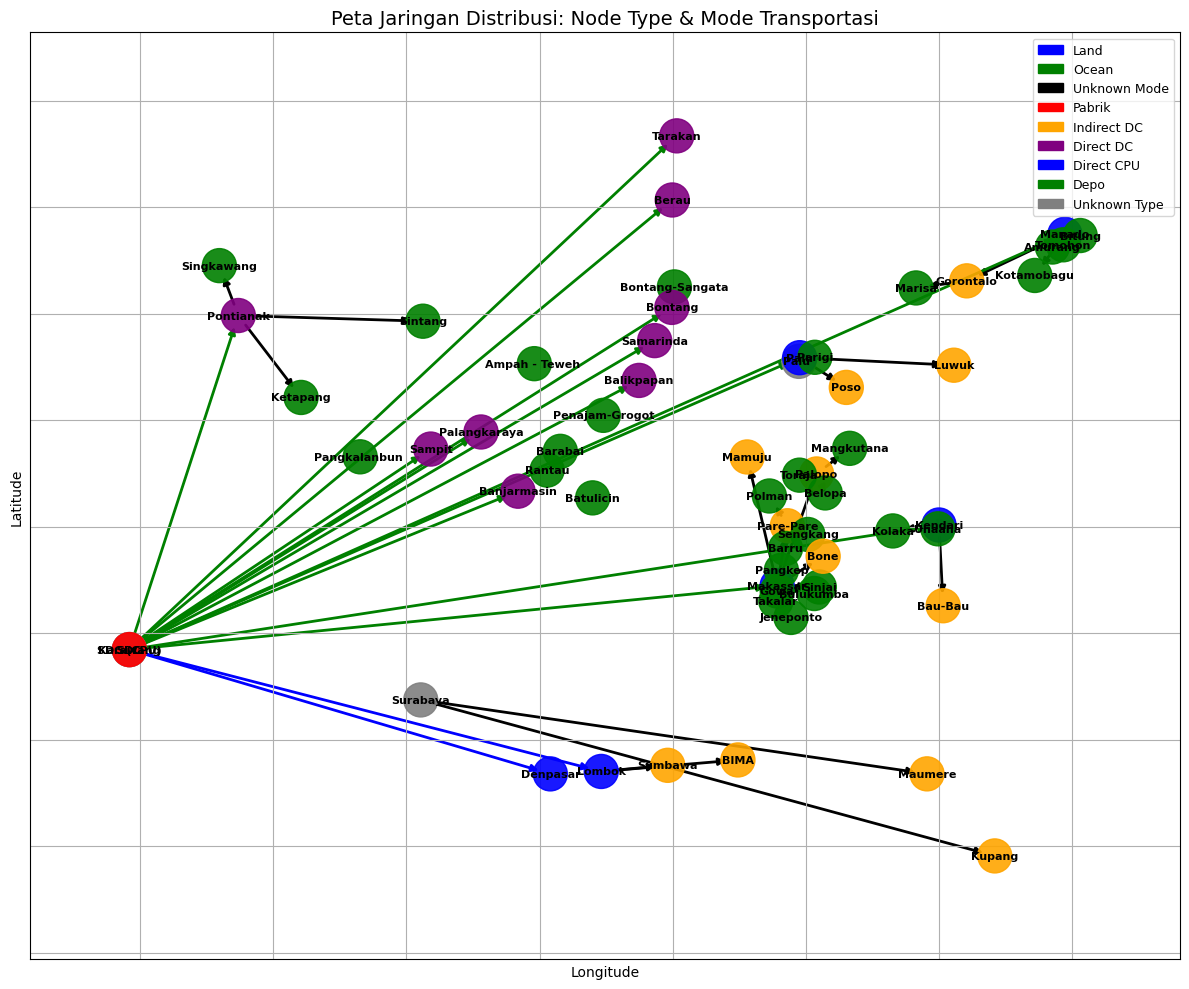

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

# --- STEP 1: Siapkan Graph dan Posisi ---
G = nx.DiGraph()

# Buat mapping node_type dari node_id
node_type_dict = dict(zip(df['to_node'], df['node_type']))

# Gabungkan node asal dan tujuan
nodes = pd.concat([
    df[['from_node', 'from_latitude', 'from_longitude']].rename(
        columns={'from_node': 'node', 'from_latitude': 'lat', 'from_longitude': 'lon'}),
    df[['to_node', 'to_latitude', 'to_longitude']].rename(
        columns={'to_node': 'node', 'to_latitude': 'lat', 'to_longitude': 'lon'})
]).dropna(subset=['node']).drop_duplicates(subset='node')

# Tambahkan kolom node_type ke DataFrame nodes berdasarkan mapping
nodes['node_type'] = nodes['node'].map(node_type_dict)

# Mapping warna node berdasarkan jenisnya
node_type_colors = {
    'Pabrik': 'red',
    'Indirect DC': 'orange',
    'Direct DC': 'purple',
    'Direct CPU': 'blue',
    'Depo': 'green'
}

# Tambahkan node ke graf beserta pos dan type
for _, row in nodes.iterrows():
    tipe = row['node_type'] if pd.notna(row['node_type']) else 'Unknown'
    G.add_node(row['node'], pos=(row['lon'], row['lat']), node_type=tipe)

# --- STEP 2: Tambahkan Edge berdasarkan mode_type ---
for _, row in df.dropna(subset=['from_node', 'to_node']).iterrows():
    mode = str(row['mode_type']).lower() if pd.notna(row['mode_type']) else 'unknown'

    if mode == 'ocean':
        color = 'green'
    elif mode == 'land':
        color = 'blue'
    else:
        color = 'black'

    G.add_edge(row['from_node'], row['to_node'], color=color, mode=mode)

# --- STEP 3: Visualisasi ---
pos = nx.get_node_attributes(G, 'pos')
edge_colors = [G[u][v]['color'] for u, v in G.edges()]
node_types = nx.get_node_attributes(G, 'node_type')
node_colors = [node_type_colors.get(node_types.get(n, 'Unknown'), 'gray') for n in G.nodes()]

plt.figure(figsize=(12, 10))

# Gambar node berwarna
nx.draw_networkx_nodes(G, pos, node_size=600, node_color=node_colors, alpha=0.9)

# Gambar edge
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2)

# Gambar label node
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

# --- Legenda Warna Edge ---
legend_edges = [
    mpatches.Patch(color='blue', label='Land'),
    mpatches.Patch(color='green', label='Ocean'),
    mpatches.Patch(color='black', label='Unknown Mode')
]

# --- Legenda Warna Node ---
legend_nodes = [
    mpatches.Patch(color='red', label='Pabrik'),
    mpatches.Patch(color='orange', label='Indirect DC'),
    mpatches.Patch(color='purple', label='Direct DC'),
    mpatches.Patch(color='blue', label='Direct CPU'),
    mpatches.Patch(color='green', label='Depo'),
    mpatches.Patch(color='gray', label='Unknown Type')
]

plt.legend(handles=legend_edges + legend_nodes, loc='upper right', fontsize=9)

plt.title("Peta Jaringan Distribusi: Node Type & Mode Transportasi", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


In [80]:
missing_coords = df[
    df[['from_latitude', 'from_longitude', 'to_latitude', 'to_longitude']].isnull().any(axis=1)
]

print("Baris dengan koordinat tidak lengkap:")
print(missing_coords[['from_node', 'to_node', 'from_latitude', 'from_longitude', 'to_latitude', 'to_longitude']])


Baris dengan koordinat tidak lengkap:
   from_node          to_node  from_latitude  from_longitude  to_latitude  \
0        NaN   Ampah - Teweh             NaN             NaN    -0.935414   
2        NaN          Barabai            NaN             NaN    -2.581936   
4        NaN        Batulicin            NaN             NaN    -3.455801   
7        NaN  Bontang-Sangata            NaN             NaN     0.505968   
16       NaN    Pangkalanbun             NaN             NaN    -2.684718   
19       NaN   Penajam-Grogot            NaN             NaN    -1.905754   
21       NaN           Rantau            NaN             NaN    -2.934015   
71      None         Karawang            NaN             NaN    -6.305384   

    to_longitude  
0     114.901123  
2     115.390569  
4     115.997490  
7     117.532558  
16    111.631067  
19    116.197743  
21    115.141980  
71    107.296913  


In [81]:
df_clean = df.dropna(subset=['from_latitude', 'from_longitude', 'to_latitude', 'to_longitude']).copy()

from geopy.distance import geodesic

df_clean['distance_km'] = df_clean.apply(lambda row:
    geodesic((row['from_latitude'], row['from_longitude']),
             (row['to_latitude'], row['to_longitude'])).km,
    axis=1
)

df_clean['distance_km'] = df_clean['distance_km'].round(2)


In [82]:
df_clean.head()

,node_id,node_type,to_node,region,to_latitude,to_longitude,from_node,mode,volume_cbm,cost_idr,mode_type,from_latitude,from_longitude,distance_km
1,DC002,Depo,Amurang,BCP Outer,1.25533,124.63187,Manado,NaN,NaN,NaN,NaN,1.49518,124.86597,37.18
3,DC004,Depo,Barru,BCP Outer,-4.40562,119.61877,Pare-Pare,NaN,NaN,NaN,NaN,-3.97929,119.65472,47.31
5,DC006,Depo,Belopa,BCP Outer,-3.36284,120.36455,Palopo,NaN,NaN,NaN,NaN,-3.00675,120.20264,43.29
6,DC007,Depo,Bitung,BCP Outer,1.47110,125.15311,Manado,NaN,NaN,NaN,NaN,1.49518,124.86597,32.06
8,DC009,Depo,Bulukumba,BCP Outer,-5.25188,120.15831,Makassar,NaN,NaN,NaN,NaN,-5.10404,119.46298,78.80


In [83]:
df_model = df_clean[[
    'from_node', 'to_node', 'mode', 'mode_type', 'volume_cbm', 'distance_km', 'cost_idr'
]].dropna()


In [84]:
df_model.columns



Index(['from_node', 'to_node', 'mode', 'mode_type', 'volume_cbm',
       'distance_km', 'cost_idr'],
      dtype='object')

In [85]:
df_model.sample(10)

,from_node,to_node,mode,mode_type,volume_cbm,distance_km,cost_idr
52,SDC,Pontianak,40FT,Ocean,2360,730.07,17943460.0
49,SDC,Palangkaraya,20FT,Ocean,1160,861.07,13705881.0
58,SDC,Tarakan,40FT,Ocean,2360,1563.30,30964348.0
33,SDC,Kendari,40FT,Ocean,2360,1705.38,27500000.0
47,SDC,Berau,20FT,Ocean,1160,1468.29,17082458.0
53,SDC,Samarinda,20FT,Ocean,1160,1269.83,11954915.0
55,SDC,Sampit,20FT,Ocean,1160,753.61,15536568.0
54,SDC,Samarinda,40FT,Ocean,2360,1269.83,23263192.0
32,SDC,Kendari,20FT,Ocean,1160,1705.38,17200000.0
38,SDC,Makassar,40FT,Ocean,2360,1354.14,15000000.0


In [86]:
df_kendaraan_info = pd.DataFrame({
    'type': ['CDD', 'CDE', 'GrandMax', 'Kijang', 'Motorbike'],
    'kapasitas_cbm': [280, 200, 120, 80, 5],
    'petrol_per_100km': [4, 7, 8, 10, 15]
})


In [87]:
df_resources.columns

Index(['Region', 'Branch', 'CDD', 'CDE', 'GrandMax', 'Kijang', 'Driver',
       'Staff', 'CDD Cost', 'CDE Cost', 'GrandMax Cost', 'Kijang Cost',
       'Driver Cost', 'Staff Cost', 'CDD Total', 'CDE Total', 'GrandMax Total',
       'Kijang Total', 'Driver Total', 'Fleet Fixed Cost/Day',
       'Fleet Variable Cost/Day', 'People Cost/Day', 'Transport All In/Day',
       'Capacity', 'Branch_lower'],
      dtype='object')

In [88]:
# --- STEP 2: Ambil dari df_resources ---
vehicle_cols = ['CDD', 'CDE', 'GrandMax', 'Kijang']
df_vehicle = df_resources[['Branch'] + vehicle_cols].copy()

# Pastikan semua kolom kendaraan numerik
for col in vehicle_cols:
    df_vehicle[col] = pd.to_numeric(df_vehicle[col], errors='coerce').fillna(0)

# --- STEP 3: Long Format ---
df_long = df_vehicle.melt(id_vars='Branch', var_name='type', value_name='jumlah_unit')
df_long = df_long[df_long['jumlah_unit'] > 0]

# Gabung dengan info kapasitas & BBM
df_long = df_long.merge(df_kendaraan_info, on='type', how='left')

# Hitung total kapasitas dan konsumsi BBM
df_long['total_kapasitas'] = df_long['jumlah_unit'] * df_long['kapasitas_cbm']
df_long['total_petrol'] = df_long['jumlah_unit'] * df_long['petrol_per_100km']

# --- STEP 4: Agregasi per Branch ---
df_summary = df_long.groupby('Branch').agg({
    'jumlah_unit': 'sum',
    'total_kapasitas': 'sum',
    'total_petrol': 'sum'
}).reset_index()

df_summary = df_summary.rename(columns={
    'jumlah_unit': 'origin_total_vehicle',
    'total_kapasitas': 'origin_total_capacity_cbm',
    'total_petrol': 'origin_total_petrol_per_100km'
})

df_summary['origin_avg_petrol_per_100km'] = (
    df_summary['origin_total_petrol_per_100km'] / df_summary['origin_total_vehicle']
).round(2)

# --- STEP 5: One-hot ketersediaan kendaraan ---
df_availability = df_vehicle.copy()
for col in vehicle_cols:
    df_availability[col] = (df_availability[col] > 0).astype(int)

df_availability = df_availability.rename(columns={
    'CDD': 'CDD_available',
    'CDE': 'CDE_available',
    'GrandMax': 'GrandMax_available',
    'Kijang': 'Kijang_available'
})

# --- FINAL OUTPUT ---
print("✅ df_summary:")
print(df_summary.head())

print("\n✅ df_availability:")
print(df_availability.head())

✅ df_summary:
        Branch  origin_total_vehicle  origin_total_capacity_cbm  \
0         Bali                  19.0                     3880.0   
1   Balikpapan                  14.0                     2880.0   
2  Banjarmasin                  26.0                     5280.0   
3      Bau-Bau                   1.0                      200.0   
4        Berau                   3.0                      520.0   

   origin_total_petrol_per_100km  origin_avg_petrol_per_100km  
0                          130.0                         6.84  
1                           89.0                         6.36  
2                          167.0                         6.42  
3                            7.0                         7.00  
4                           20.0                         6.67  

✅ df_availability:
    Branch  CDD_available  CDE_available  GrandMax_available  Kijang_available
0     Bima              0              1                   0                 0
1   Lombok           

In [89]:
df_middle_cleaned.head()

,Distributor Area,Origin Area,Origin Latitude,Longitude_x,Destination Area,Destination Latitude,Destination Longitude,Volume (CS),distance_km
0,Bali Nusra,Denpasar,-8.63955,115.20248,Lombok,-8.59373,116.15876,1000,105.38
1,Bali Nusra,Lombok,-8.59373,116.15876,Denpasar,-8.63955,115.20248,1000,105.38
2,Bali Nusra,Denpasar,-8.63955,115.20248,BIMA,-8.37759,118.72564,500,388.99
3,Bali Nusra,Denpasar,-8.63955,115.20248,Kupang,-10.18017,123.54942,500,932.41
4,Bali Nusra,Denpasar,-8.63955,115.20248,Maumere,-8.63907,122.27671,500,778.61


In [100]:
df_final = df_middle_cleaned.merge(
    df_summary, left_on='origin_area', right_on='Branch', how='left'
).drop(columns='Branch')

df_final = df_final.merge(
    df_availability, left_on='origin_area', right_on='Branch', how='left'
).drop(columns='Branch')


KeyError: 'origin_area'

In [102]:
newxls = "Dataset/Dataset Bersih Lengkap.xlsx"
df_customer = pd.read_excel(newxls, sheet_name="Customer Final")

In [103]:
df_customer.head()
# Ambil kolom-kolom yang diperlukan dari df_customer
df_customer_filtered = df_customer[[
    'Customer ID',
    'Sub-District Area',
    'Latitude',
    'Longitude',
    'Avg Monthly Demand (box)'
]].copy()
df_customer_filtered.head()


,Customer ID,Sub-District Area,Latitude,Longitude,Avg Monthly Demand (box)
0,CUST000001,East Kalimantan,4.145344,117.912634,47.836860
1,CUST000002,East Kalimantan,4.145344,117.912634,10.774181
2,CUST000003,East Kalimantan,4.144048,117.912500,5.733333
3,CUST000004,East Kalimantan,4.144048,117.912500,1.541669
4,CUST000005,East Kalimantan,4.143269,117.654593,12.515233


In [104]:
import pandas as pd

# 1. Baca sheet Resources dengan header di baris ke-3
df_region = pd.read_excel(file_path, sheet_name='Resources', header=3, usecols=['REGION', 'BRANCH'])

# 2. Bersihkan dan lowercase
df_region['BRANCH'] = df_region['BRANCH'].str.strip().str.lower()
df_region['REGION'] = df_region['REGION'].str.strip()

# Ganti 'bali' menjadi 'denpasar' di df_region
df_region['BRANCH'] = df_region['BRANCH'].replace('bali', 'denpasar')

# 3. Standardisasi df_dc_demand
df_dc_demand['Area'] = df_dc_demand['Area'].str.strip().str.lower()

# 4. Join berdasarkan Area dan Branch
df_dc_enriched = df_dc_demand.merge(
    df_region.drop_duplicates(),
    how='left',
    left_on='Area',
    right_on='BRANCH'
)

# 5. Drop kolom BRANCH (optional)
df_dc_enriched.drop(columns=['BRANCH'], inplace=True)

# 6. Tangani Area yang REGION-nya masih NaN → isi "Unknown"
# 6. Tangani NaN di REGION:
# Jika Type == 'Depo', isi REGION = 'Depo'
# Jika tidak, isi REGION = 'Unknown'
df_dc_enriched['REGION'] = df_dc_enriched.apply(
    lambda row: 'Depo' if pd.isna(row['REGION']) and row['Type'].lower() == 'depo' else (
        'Unknown' if pd.isna(row['REGION']) else row['REGION']
    ),
    axis=1
)

# 7. Contoh hasil
print(df_dc_enriched[['DC ID', 'Area', 'REGION']].sample(10))


    DC ID            Area      REGION
40  DC020  penajam-grogot        Depo
53  DC045         tarakan  Kalimantan
27  DC034        makassar    Sulawesi
32  DC053         maumere         BNT
19  DC011       jeneponto        Depo
49  DC025          sinjai        Depo
21  DC012        ketapang        Depo
39  DC019          parigi        Depo
8   DC006          belopa        Depo
0   DC001   ampah - teweh        Depo


C:\Users\Bara\AppData\Local\Temp\ipykernel_31048\172746499.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dc_demand['Area'] = df_dc_demand['Area'].str.strip().str.lower()


In [105]:
df_dc_enriched.head()

,Area,DC ID,Distributor Area,Type,Sent From,Latitude,Longitude,Monthly Demand (Average FY2021) - Carton,Max Demand - FY2021 - Carton,REGION
0,ampah - teweh,DC001,Kalimantan,Depo,NaN,-0.935414,114.901123,NaN,NaN,Depo
1,amurang,DC002,BCP Outer,Depo,Manado,1.255330,124.631870,NaN,NaN,Depo
2,balikpapan,DC037,Kalimantan,Direct DC,SDC,-1.249963,116.868785,10546.0,12817.0,Kalimantan
3,banjarmasin,DC038,Kalimantan,Direct DC,SDC,-3.330249,114.595582,24354.0,38897.0,Kalimantan
4,barabai,DC003,Kalimantan,Depo,NaN,-2.581936,115.390569,NaN,NaN,Depo


In [106]:
df_dc_enriched['REGION'].value_counts().reset_index().rename(
    columns={'index': 'REGION', 'REGION': 'Jumlah DC'}
)


,Jumlah DC,count
0,Depo,30
1,Sulawesi,12
2,Kalimantan,7
3,BNT,5
4,Unknown,3


In [107]:
import pandas as pd
from geopy.distance import geodesic

# PARAMETER
MAX_DELIVERY_DISTANCE = 100000  # km, batas maksimal jarak realistis

# Step 1: Filter DC (tanpa Pabrik / SDC)
df_dc_deliver = df_dc_enriched[df_dc_enriched['Type'] != 'Pabrik'].copy()
df_dc_deliver['Remaining Capacity'] = df_dc_deliver['Max Demand - FY2021 - Carton'].copy()

# Step 2: Sampling customer (bisa 117k++ nanti kalau sudah stabil)
# df_customer_sample = df_customer.sample(n=50000, random_state=100)

# Step 3: Alokasi
allocation_result = []

for idx, cust in df_customer_filtered.iterrows():
    cust_coord = (cust['Latitude'], cust['Longitude'])
    cust_demand = cust['Avg Monthly Demand (box)']
    
    # Hitung jarak ke semua DC
    dc_distances = []
    for _, dc in df_dc_deliver.iterrows():
        dc_coord = (dc['Latitude'], dc['Longitude'])
        dist = geodesic(cust_coord, dc_coord).km
        dc_distances.append((dc['DC ID'], dist, dc['Type']))
    
    # Urutkan berdasarkan Jarak dan Preferensi Type
    dc_distances.sort(key=lambda x: (x[1], {'Direct DC': 0, 'Direct CPU': 0, 'Indirect DC': 1, 'Indirect CPU': 1, 'Depo': 2}.get(x[2], 3)))
    
    # Alokasikan ke DC yang kapasitasnya cukup dan jaraknya wajar
    assigned = False
    for dc_id, dist, dc_type in dc_distances:
        if dist > MAX_DELIVERY_DISTANCE:
            continue  # Skip terlalu jauh
        
        dc_index = df_dc_deliver[df_dc_deliver['DC ID'] == dc_id].index[0]
        remaining = df_dc_deliver.at[dc_index, 'Remaining Capacity']
        
        if remaining >= cust_demand:
            df_dc_deliver.at[dc_index, 'Remaining Capacity'] -= cust_demand
            allocation_result.append({
                'Customer ID': cust['Customer ID'],
                'Latitude': cust['Latitude'],
                'Longitude': cust['Longitude'],
                'Nearest DC ID': dc_id,
                'Distance to DC (km)': round(dist, 2),
                'Avg Monthly Demand (box)': cust_demand
            })
            assigned = True
            break

    if not assigned:
        allocation_result.append({
            'Customer ID': cust['Customer ID'],
            'Latitude': cust['Latitude'],
            'Longitude': cust['Longitude'],
            'Nearest DC ID': 'UNASSIGNED',
            'Distance to DC (km)': None,
            'Avg Monthly Demand (box)': cust_demand
        })

# Step 4: Buat DataFrame hasil
df_customer_assigned = pd.DataFrame(allocation_result)

# Step 5: Total demand per DC
df_demand_per_dc = df_customer_assigned[df_customer_assigned['Nearest DC ID'] != 'UNASSIGNED'] \
    .groupby('Nearest DC ID')['Avg Monthly Demand (box)'].sum().reset_index()
df_demand_per_dc.columns = ['DC ID', 'Total Demand (box)']

# Step 6: Save ke CSV
df_demand_per_dc.to_csv('demand_per_dc.csv', index=False)
df_customer_assigned.to_csv('customer_assigned_to_dc.csv', index=False)

# Step 7: Pemetaan Region/Area
df_customer_assigned_with_area = df_customer_assigned.merge(
    df_dc_deliver[['DC ID', 'Distributor Area', 'REGION']],
    left_on='Nearest DC ID',
    right_on='DC ID',
    how='left'
)

df_demand_per_area = df_customer_assigned_with_area[df_customer_assigned_with_area['Nearest DC ID'] != 'UNASSIGNED'] \
    .groupby('REGION')['Avg Monthly Demand (box)'].sum().reset_index()

# Output akhir
print(df_demand_per_area)
print("✅ Hasil demand per DC disimpan ke 'demand_per_dc.csv'")
print("✅ Pemetaan customer disimpan ke 'customer_assigned_to_dc.csv'")


KeyboardInterrupt: 

In [108]:
print(df_dc_deliver['REGION'].unique())


['Depo' 'Kalimantan' 'Sulawesi' 'BNT' 'Unknown']


In [109]:
df_dc_demand['Area'] = df_dc_demand['Area'].str.strip().str.lower()
df_dc_demand['Area'] = df_dc_demand['Area'].replace('denpasar', 'bali')  # mapping Denpasar jadi Bali


C:\Users\Bara\AppData\Local\Temp\ipykernel_31048\256548457.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dc_demand['Area'] = df_dc_demand['Area'].str.strip().str.lower()
C:\Users\Bara\AppData\Local\Temp\ipykernel_31048\256548457.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dc_demand['Area'] = df_dc_demand['Area'].replace('denpasar', 'bali')  # mapping Denpasar jadi Bali


In [110]:
import pandas as pd
from geopy.distance import geodesic
from collections import defaultdict

# PARAMETER
MAX_DELIVERY_DISTANCE = 100000  # optional, tetap disimpan

# Step 1: Filter DC (tanpa Pabrik / SDC)
df_dc_deliver = df_dc_enriched[df_dc_enriched['Type'] != 'Pabrik'].copy()
df_dc_deliver['Remaining Capacity'] = pd.to_numeric(df_dc_deliver['Max Demand - FY2021 - Carton'], errors='coerce').fillna(0)

# Step 2: Customer
# df_customer_sample = df_customer.copy()
# df_customer_sample = df_customer_filtered.sample(n=3000, random_state=100)

# Step 3: Alokasi + log overcapacity
allocation_result = []
over_capacity_log = defaultdict(float)

for idx, cust in df_customer_filtered.iterrows():
    cust_coord = (cust['Latitude'], cust['Longitude'])
    cust_demand = cust['Avg Monthly Demand (box)']
    
    # Hitung jarak ke semua DC
    dc_distances = []
    for _, dc in df_dc_deliver.iterrows():
        dc_coord = (dc['Latitude'], dc['Longitude'])
        dist = geodesic(cust_coord, dc_coord).km
        dc_distances.append((dc['DC ID'], dist, dc['Type']))
    
    # Urutkan berdasarkan jarak & preferensi tipe
    dc_distances.sort(key=lambda x: (x[1], {'Direct DC': 0, 'Direct CPU': 0, 'Indirect DC': 1, 'Indirect CPU': 1, 'Depo': 2}.get(x[2], 3)))
    
    assigned = False
    for dc_id, dist, dc_type in dc_distances:
        dc_index = df_dc_deliver[df_dc_deliver['DC ID'] == dc_id].index
        if len(dc_index) == 0:
            continue
        dc_index = dc_index[0]
        remaining = df_dc_deliver.at[dc_index, 'Remaining Capacity']
        
        if remaining >= cust_demand:
            # Cukup kapasitas → alokasi normal
            df_dc_deliver.at[dc_index, 'Remaining Capacity'] -= cust_demand
            allocation_result.append({
                'Customer ID': cust['Customer ID'],
                'Latitude': cust['Latitude'],
                'Longitude': cust['Longitude'],
                'Nearest DC ID': dc_id,
                'Distance to DC (km)': round(dist, 2),
                'Avg Monthly Demand (box)': cust_demand,
                'Over Capacity': False
            })
            assigned = True
            break

    if not assigned:
        # Tetap paksa assign ke DC terdekat (meskipun over capacity)
        dc_id, dist, dc_type = dc_distances[0]
        dc_index = df_dc_deliver[df_dc_deliver['DC ID'] == dc_id].index[0]
        df_dc_deliver.at[dc_index, 'Remaining Capacity'] -= cust_demand
        over_capacity_log[dc_id] += cust_demand

        allocation_result.append({
            'Customer ID': cust['Customer ID'],
            'Latitude': cust['Latitude'],
            'Longitude': cust['Longitude'],
            'Nearest DC ID': dc_id,
            'Distance to DC (km)': round(dist, 2),
            'Avg Monthly Demand (box)': cust_demand,
            'Over Capacity': True
        })

# Step 4: Buat DataFrame hasil alokasi
df_customer_assigned = pd.DataFrame(allocation_result)

# Step 5: Buat DataFrame log DC over capacity
df_over_capacity_log = pd.DataFrame([
    {'DC ID': dc_id, 'Total Over Capacity (box)': total}
    for dc_id, total in over_capacity_log.items()
])

# Output hasil
df_customer_assigned_sample = df_customer_assigned.sample(10)
df_over_capacity_log_sample = df_over_capacity_log.sample(min(10, len(df_over_capacity_log)))

print("📦 Contoh hasil alokasi customer:")
print(df_customer_assigned_sample)

print("\n⚠️ Contoh log DC over capacity:")
print(df_over_capacity_log_sample)

# Save hasil customer assignment ke CSV
df_customer_assigned.to_csv('customer_assigned_to_dc.csv', index=False)
print("✅ File 'customer_assigned_to_dc.csv' berhasil disimpan.")

# Step 7: Pemetaan Region/Area
df_customer_assigned_with_area = df_customer_assigned.merge(
    df_dc_deliver[['DC ID', 'Distributor Area', 'REGION']],
    left_on='Nearest DC ID',
    right_on='DC ID',
    how='left'
)

df_demand_per_area = df_customer_assigned_with_area[df_customer_assigned_with_area['Nearest DC ID'] != 'UNASSIGNED'] \
    .groupby('REGION')['Avg Monthly Demand (box)'].sum().reset_index()

# Output akhir
print(df_demand_per_area)


KeyboardInterrupt: 

In [111]:
print(df_dc_deliver[df_dc_deliver['REGION'] == 'BNT'][['DC ID', 'Area', 'Remaining Capacity']])


    DC ID     Area  Remaining Capacity
10  DC047     bima              4718.0
24  DC050   kupang              9680.0
25  DC033   lombok             18762.0
32  DC053  maumere              5389.0
51  DC057  sumbawa              3953.0


In [ ]:
# import folium
# from folium.plugins import MarkerCluster

# # Buat map awal, posisinya di tengah-tengah Indonesia
# m = folium.Map(location=[-2.5, 118], zoom_start=5)

# # --- 1. Tambahkan marker untuk DC ---
# for idx, row in df_dc_deliver.iterrows():
#     folium.CircleMarker(
#         location=[row['Latitude'], row['Longitude']],
#         radius=8,
#         color='blue',
#         fill=True,
#         fill_opacity=0.7,
#         popup=f"DC: {row['DC ID']}<br>Area: {row['Area']}",
#     ).add_to(m)

# # --- 2. Tambahkan marker untuk customer (pakai cluster biar ga rame) ---
# customer_cluster = MarkerCluster(name="Customers").add_to(m)

# for idx, row in df_customer_filtered.iterrows():
#     folium.CircleMarker(
#         location=[row['Latitude'], row['Longitude']],
#         radius=3,
#         color='red',
#         fill=True,
#         fill_opacity=0.5,
#         popup=f"Customer ID: {row['Customer ID']}",
#     ).add_to(customer_cluster)
 
# # Simpan map-nya
# m.save('map_dc_customer.html')
# print("✅ Map berhasil disimpan ke 'map_dc_customer.html'")


KeyboardInterrupt: 

# Mempersiapkan untuk bangun model

In [113]:
df_edges.head()

,from_dc,to_area,mode,volume_cbm,cost_idr,mode_type
0,DC031,Denpasar,Build Up (40 CBM),1600,12500000.0,Land
1,DC031,Denpasar,FUSO (22 CBM),880,8682800.0,Land
2,DC033,Lombok,Build Up (40 CBM),1600,23500000.0,Land
3,DC033,Lombok,CDD (7 CBM),280,13000000.0,Land
4,DC033,Lombok,FUSO (22 CBM),880,17500000.0,Land


In [114]:
df_oceanland = df_edges.copy()

# Rename untuk konsistensi
df_oceanland = df_oceanland.rename(columns={
    'from_dc': 'target_node',
    'mode': 'moda',
    'cost_idr': 'cost_per_trip',
    'volume_cbm': 'volume_per_trip'
})

# Tambahkan kolom source_node sebagai SDC
df_oceanland['source_node'] = 'SDC'  # atau nama ID pabrikmu


# Ambil kolom penting untuk df_edges_final
df_oceanland = df_oceanland[['source_node', 'target_node', 'moda', 'cost_per_trip', 'volume_per_trip']]

# Rename untuk konsistensi
df_oceanland = df_oceanland.rename(columns={
    'from_dc': 'target_node',
    'moda': 'mode_type',
    'cost_idr': 'cost_per_trip',
    'volume_cbm': 'volume_per_trip'
})

df_oceanland.head()

,source_node,target_node,mode_type,cost_per_trip,volume_per_trip
0,SDC,DC031,Build Up (40 CBM),12500000.0,1600
1,SDC,DC031,FUSO (22 CBM),8682800.0,880
2,SDC,DC033,Build Up (40 CBM),23500000.0,1600
3,SDC,DC033,CDD (7 CBM),13000000.0,280
4,SDC,DC033,FUSO (22 CBM),17500000.0,880


In [115]:
df_middle_edge_list.head()

,origin_id,destination_id,distance_km,max_volume
0,DC031,DC033,105.38,1000
1,DC033,DC031,105.38,1000
2,DC031,DC047,388.99,500
3,DC031,DC050,932.41,500
4,DC031,DC053,778.61,500


In [116]:
df_resources_joined.head()

,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity,dc_id
0,BNT,Bima,0.0,2.0,0.0,0.0,3.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,11269866.0,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0,DC047
1,BNT,Lombok,1.0,6.0,1.0,0.0,18.0,9.0,6900000.0,5500000.0,...,33000000.0,3500000.0,0.0,67619196.0,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0,DC033
2,BNT,Kupang,3.0,2.0,0.0,0.0,8.0,4.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,30052976.0,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0,DC050
3,BNT,Sumbawa,0.0,1.0,1.0,0.0,4.0,3.0,6900000.0,5500000.0,...,5500000.0,3500000.0,0.0,15026488.0,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0,DC057
4,BNT,Maumere,2.0,2.0,0.0,0.0,5.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,18783110.0,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0,DC053


buat order constraint (c3)

In [117]:
import pandas as pd

# Contoh: load data dari Excel (ubah sesuai kebutuhanmu)
df_stp = pd.read_excel(xls, sheet_name="STP Performance")

# Jika sudah berupa DataFrame df_stp:
def parse_order_schedule(order_schedule):
    # Bersihkan spasi dan pisah berdasarkan koma atau strip
    days = []
    if pd.isna(order_schedule):
        return []
    parts = order_schedule.replace('-', ',').replace(' ', '').split(',')
    for p in parts:
        if p != '':
            days.append(p.strip().capitalize())  # capitalized (Mon, Tue, ...)
    return days

def transform_stp_to_order_constraints(df_stp):
    # Rename kolom agar lebih seragam
    df = df_stp.rename(columns={
        'Ship to Point': 'target_node',
        'Current Lead Time\nSO/LO': 'lead_time_days',
        'Order \nSchedule': 'order_schedule',
        'Order/Wk': 'order_wk'
    })

    # Parse kolom hari kirim
    df['valid_days'] = df['order_schedule'].apply(parse_order_schedule)

    # Ambil kolom penting
    df_out = df[['target_node', 'order_wk', 'valid_days', 'lead_time_days']].copy()

    # Normalisasi node name (opsional, misal: uppercase)
    df_out['target_node'] = df_out['target_node'].str.upper().str.strip()

    return df_out

# Contoh pemakaian:
df_order_constraints = transform_stp_to_order_constraints(df_stp)


In [118]:
df_order_constraints.head()

,target_node,order_wk,valid_days,lead_time_days
0,BORWITA CITRA PRIMA - BALI,3,"[Mon, Sat]",7
1,PT. BORWITA CITRA PRIMA - KENDARI,2,"[Mon, Sat]",14
2,PT. BORWITA CITRA PRIMA - LOMBOK,2,"[Mon, Sat]",9
3,BORWITA CITRA PRIMA MAKASAR,3,"[Mon, Sat]",14
4,BORWITA CITRA PRIMA-MANADO,2,"[Mon, Sat]",20


In [119]:
df_resources_joined

,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity,dc_id
0,BNT,Bima,0.00,2.000000,0.000,0.0,3.0,3.0,6900000.0,5.500000e+06,...,1.100000e+07,0.000000e+00,0.000000e+00,1.126987e+07,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0,DC047
1,BNT,Lombok,1.00,6.000000,1.000,0.0,18.0,9.0,6900000.0,5.500000e+06,...,3.300000e+07,3.500000e+06,0.000000e+00,6.761920e+07,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0,DC033
2,BNT,Kupang,3.00,2.000000,0.000,0.0,8.0,4.0,6900000.0,5.500000e+06,...,1.100000e+07,0.000000e+00,0.000000e+00,3.005298e+07,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0,DC050
3,BNT,Sumbawa,0.00,1.000000,1.000,0.0,4.0,3.0,6900000.0,5.500000e+06,...,5.500000e+06,3.500000e+06,0.000000e+00,1.502649e+07,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0,DC057
4,BNT,Maumere,2.00,2.000000,0.000,0.0,5.0,3.0,6900000.0,5.500000e+06,...,1.100000e+07,0.000000e+00,0.000000e+00,1.878311e+07,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0,DC053
5,BNT,Bali,1.00,18.000000,0.000,0.0,41.0,21.0,6900000.0,5.500000e+06,...,9.900000e+07,0.000000e+00,0.000000e+00,1.540215e+08,4.073077e+06,3800000.0,5.923904e+06,1.379698e+07,3880.0,NaN
6,Sulawesi,Bau-Bau,0.00,1.000000,0.000,0.0,2.0,2.0,6900000.0,5.500000e+06,...,5.500000e+06,0.000000e+00,0.000000e+00,6.635238e+06,2.115385e+05,200000.0,2.552015e+05,6.667399e+05,200.0,DC046
7,Sulawesi,Bone,0.00,3.000000,0.000,0.0,7.0,3.0,6900000.0,5.500000e+06,...,1.650000e+07,0.000000e+00,0.000000e+00,2.880947e+07,6.346154e+05,600000.0,1.108057e+06,2.342672e+06,600.0,DC048
8,Sulawesi,Luwuk,0.00,1.000000,1.000,0.0,3.0,2.0,6900000.0,5.500000e+06,...,5.500000e+06,3.500000e+06,0.000000e+00,1.126987e+07,3.461538e+05,400000.0,4.334564e+05,1.179610e+06,320.0,DC051
9,Sulawesi,Kendari,3.00,4.000000,0.000,0.0,12.0,6.0,6900000.0,5.500000e+06,...,2.200000e+07,0.000000e+00,0.000000e+00,4.319004e+07,1.642308e+06,1400000.0,1.661156e+06,4.703463e+06,1640.0,DC032


In [120]:
vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'Kijang']
mode_param = {
    'CDD': 70,
    'CDE': 100,
    'GrandMax': 120,
    'Kijang': 50
}

# Simulasi data
# df_resource_joined = df_resources.copy()

# Bersihkan dan bentuk long format dari df_resource_joined
resource_edges_v2 = []
for _, row in df_resources_joined.iterrows():
    origin = row['dc_id']
    if pd.isna(origin):
        continue
    for mode in vehicle_modes:
        jumlah = row[mode]
        cost = row[f'{mode} Cost']
        if pd.notna(jumlah) and pd.notna(cost) and jumlah > 0 and cost > 0:
            resource_edges_v2.append({
                'source_node': origin,
                'mode_type': mode,
                'cost_per_trip': cost,
                'volume_per_trip': mode_param[mode]
            })

df_mode_per_dc_v2 = pd.DataFrame(resource_edges_v2)

# Gabungkan ke df_middle_edge_list
df_middle_expanded_v2 = df_middle_edge_list.merge(
    df_mode_per_dc_v2,
    left_on='origin_id',
    right_on='source_node',
    how='left'
)

# Filter hanya kombinasi valid
df_middle_final_v2 = df_middle_expanded_v2.dropna(subset=['mode_type'])

# Ambil kolom final
df_middle_edges_final_v2 = df_middle_final_v2[['source_node', 'destination_id', 'mode_type', 'cost_per_trip', 'volume_per_trip']]
df_middle_edges_final_v2 = df_middle_edges_final_v2.rename(columns={'destination_id': 'target_node'})

In [121]:
df_middle_edges_final_v2.sample(20)

,source_node,target_node,mode_type,cost_per_trip,volume_per_trip
24,DC050,DC047,CDE,5.500000e+06,100.0
194,DC039,DC003,GrandMax,6.560843e+06,120.0
723,DC056,DC049,CDD,6.900000e+06,70.0
1357,DC049,DC011,CDE,5.500000e+06,100.0
1358,DC049,DC011,GrandMax,3.500000e+06,120.0
1179,DC034,DC016,CDE,5.500000e+06,100.0
138,DC037,DC005,CDE,6.560843e+06,100.0
339,DC045,DC020,CDE,6.560843e+06,100.0
544,DC035,DC034,GrandMax,3.500000e+06,120.0
458,DC043,DC038,CDD,1.385397e+07,70.0


In [122]:
import tools

# Gabungkan df_oceanland (first mile) dengan df_middle_edges_final_v2 (middle mile)
df_edges_final = pd.concat([df_oceanland, df_middle_edges_final_v2], ignore_index=True)

# Tampilkan hasil
df_edges_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1136 entries, 0 to 1135
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_node      1136 non-null   object 
 1   target_node      1136 non-null   object 
 2   mode_type        1136 non-null   object 
 3   cost_per_trip    1136 non-null   float64
 4   volume_per_trip  1136 non-null   object 
dtypes: float64(1), object(4)
memory usage: 44.5+ KB


Masukin ke x[i,j,m]

In [123]:
from ortools.sat.python import cp_model

# Inisialisasi model
model = cp_model.CpModel()

# Asumsikan df_edges_final sudah ada
# Ambil kombinasi unik (i, j, m)
edge_tuples = list(df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None))

# Buat variabel keputusan x[i][j][m]
x = {}
for i, j, m in edge_tuples:
    x[i, j, m] = model.NewIntVar(0, 1000, f'x_{i}_{j}_{m}')


In [124]:
# Coba paksa konversi kolom volume_per_trip ke float (numerik) secara eksplisit
df_edges_final['volume_per_trip'] = pd.to_numeric(df_edges_final['volume_per_trip'], errors='coerce')

# Ulangi pembuatan dictionary volume_per_trip setelah dibersihkan
volume_per_trip = {
    (row['source_node'], row['target_node'], row['mode_type']): int(round(row['volume_per_trip']))
    for _, row in df_edges_final.iterrows()
    if pd.notna(row['volume_per_trip'])  # hanya jika bukan NaN
}

# Buat juga volume_cap_dict dari df_middle_edge_list
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

volume_cap_dict = {
    (row['origin_id'], row['destination_id']): int(round(row['max_volume']))
    for _, row in df_middle_edge_list.iterrows()
    if pd.notna(row['max_volume'])
}

# Tampilkan sebagian isi dict sebagai preview
preview_volume = dict(list(volume_per_trip.items())[:5])
preview_volume

{('SDC', 'DC031', 'Build Up (40 CBM)'): 1600,
 ('SDC', 'DC031', 'FUSO (22 CBM)'): 880,
 ('SDC', 'DC033', 'Build Up (40 CBM)'): 1600,
 ('SDC', 'DC033', 'CDD (7 CBM)'): 280,
 ('SDC', 'DC033', 'FUSO (22 CBM)'): 880}

In [125]:
from ortools.sat.python import cp_model

model = cp_model.CpModel()

# (Sebelumnya sudah bikin variabel x[i,j,m]...)

# Biaya distribusi (total_cost)
cost_terms = [
    x[i, j, m] * cost_per_trip.get((i, j, m), 0)
    for (i, j, m), var in x.items()
]
total_cost = sum(cost_terms)

# Penalti unmet demand (S1)
PENALTY_RATE = 1000
penalty_terms = []
unsatisfied = {}

for j, demand in demand_dict.items():
    sent = model.NewIntVar(0, int(demand), f"sent_{j}")
    model.Add(sent == sum(
        x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m), var in x.items() if j2 == j
    ))
    unmet = model.NewIntVar(0, int(demand), f"unmet_{j}")
    model.Add(unmet == int(demand) - sent)
    penalty_terms.append(unmet * PENALTY_RATE)
    unsatisfied[j] = unmet

total_penalty = sum(penalty_terms)

# Objective akhir
model.Minimize(total_cost + total_penalty)


NameError: name 'cost_per_trip' is not defined

# Persiapan Constraint

In [126]:
from ortools.sat.python import cp_model
model = cp_model.CpModel()

# Variabel keputusan:
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    x[i, j, m] = model.NewIntVar(0, 1000, f"x_{i}_{j}_{m}")


In [127]:
# C1: Batas volume per rute
for (i, j, m), var in x.items():
    vol_per_trip = volume_per_trip.get((i, j, m))
    if vol_per_trip is None:
        continue

    if (i, j) in volume_cap_dict:
        max_volume = volume_cap_dict[(i, j)] * 24  # asumsi 24 hari operasi
        model.Add(var * vol_per_trip <= max_volume)
    else:
        model.Add(var * vol_per_trip <= 1_000_000)

    if (i, j) in volume_cap_dict:
        max_volume = volume_cap_dict[(i, j)] * 24
        print(f"C1: {i} → {j} mode {m} | volume/trip: {vol_per_trip} | batas: {max_volume}")
        model.Add(var * vol_per_trip <= max_volume)


C1: DC033 → DC031 mode CDD | volume/trip: 70 | batas: 24000
C1: DC033 → DC031 mode CDE | volume/trip: 100 | batas: 24000
C1: DC033 → DC031 mode GrandMax | volume/trip: 120 | batas: 24000
C1: DC033 → DC047 mode CDD | volume/trip: 70 | batas: 12000
C1: DC033 → DC047 mode CDE | volume/trip: 100 | batas: 12000
C1: DC033 → DC047 mode GrandMax | volume/trip: 120 | batas: 12000
C1: DC033 → DC050 mode CDD | volume/trip: 70 | batas: 12000
C1: DC033 → DC050 mode CDE | volume/trip: 100 | batas: 12000
C1: DC033 → DC050 mode GrandMax | volume/trip: 120 | batas: 12000
C1: DC033 → DC053 mode CDD | volume/trip: 70 | batas: 12000
C1: DC033 → DC053 mode CDE | volume/trip: 100 | batas: 12000
C1: DC033 → DC053 mode GrandMax | volume/trip: 120 | batas: 12000
C1: DC033 → DC057 mode CDD | volume/trip: 70 | batas: 12000
C1: DC033 → DC057 mode CDE | volume/trip: 100 | batas: 12000
C1: DC033 → DC057 mode GrandMax | volume/trip: 120 | batas: 12000
C1: DC047 → DC050 mode CDE | volume/trip: 100 | batas: 4800
C1: D

In [128]:
df_resources_joined.head()

,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity,dc_id
0,BNT,Bima,0.0,2.0,0.0,0.0,3.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,11269866.0,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0,DC047
1,BNT,Lombok,1.0,6.0,1.0,0.0,18.0,9.0,6900000.0,5500000.0,...,33000000.0,3500000.0,0.0,67619196.0,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0,DC033
2,BNT,Kupang,3.0,2.0,0.0,0.0,8.0,4.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,30052976.0,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0,DC050
3,BNT,Sumbawa,0.0,1.0,1.0,0.0,4.0,3.0,6900000.0,5500000.0,...,5500000.0,3500000.0,0.0,15026488.0,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0,DC057
4,BNT,Maumere,2.0,2.0,0.0,0.0,5.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,18783110.0,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0,DC053


In [129]:
vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']  # sesuaikan dengan sumber datamu
DAYS_IN_MONTH = 24  # asumsi

trip_limit = {}

for _, row in df_resources_joined.iterrows():
    dc = row['dc_id']
    if pd.isna(dc):
        continue
    for mode in vehicle_modes:
        jumlah_kendaraan = row.get(mode)
        if pd.notna(jumlah_kendaraan) and jumlah_kendaraan > 0:
            trip_limit[(dc, mode)] = int(jumlah_kendaraan * DAYS_IN_MONTH)

from collections import defaultdict

# Akumulasi semua trip per (origin, mode)
trip_vars = defaultdict(list)

for (i, j, m), var in x.items():
    trip_vars[(i, m)].append(var)

# Pasang constraint per (origin, mode)
for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])
        


In [130]:
solver = cp_model.CpSolver()
status = solver.Solve(model)


for (i, m), vars_list in trip_vars.items():
    total_trip = sum(solver.Value(v) for v in vars_list)
    limit = trip_limit.get((i, m), None)
    
    if limit is not None:
        print(f"Trip C2: {i}-{m} → used: {total_trip} | limit: {limit}")
        if total_trip > limit:
            print(f"🚨 C2 VIOLATION: {i}-{m} melebihi batas trip!")


Trip C2: DC033-CDD → used: 0 | limit: 24
Trip C2: DC033-CDE → used: 0 | limit: 144
Trip C2: DC033-GrandMax → used: 0 | limit: 24
Trip C2: DC047-CDE → used: 0 | limit: 48
Trip C2: DC050-CDD → used: 0 | limit: 72
Trip C2: DC050-CDE → used: 0 | limit: 48
Trip C2: DC053-CDD → used: 0 | limit: 48
Trip C2: DC053-CDE → used: 0 | limit: 48
Trip C2: DC057-CDE → used: 0 | limit: 24
Trip C2: DC057-GrandMax → used: 0 | limit: 24
Trip C2: DC037-CDD → used: 0 | limit: 96
Trip C2: DC037-CDE → used: 0 | limit: 168
Trip C2: DC037-GrandMax → used: 0 | limit: 72
Trip C2: DC038-CDD → used: 0 | limit: 168
Trip C2: DC038-CDE → used: 0 | limit: 312
Trip C2: DC038-GrandMax → used: 0 | limit: 144
Trip C2: DC039-CDD → used: 0 | limit: 24
Trip C2: DC039-GrandMax → used: 0 | limit: 48
Trip C2: DC041-CDD → used: 0 | limit: 24
Trip C2: DC041-CDE → used: 0 | limit: 48
Trip C2: DC041-GrandMax → used: 0 | limit: 72
Trip C2: DC043-CDD → used: 0 | limit: 72
Trip C2: DC043-CDE → used: 0 | limit: 72
Trip C2: DC043-GrandMa

In [131]:
order_limit = {
    row['target_node']: int(row['order_wk'] * 4)
    for _, row in df_order_constraints.iterrows()
    if pd.notna(row['order_wk'])
}

In [132]:
from collections import defaultdict

# Akumulasi semua trip dari SDC ke j
sdctrip_vars = defaultdict(list)

for (i, j, m), var in x.items():
    if i.startswith("SDC") or i == "SDC":
        sdctrip_vars[j].append(var)

# Pasang constraint: max trip ke j sesuai jadwal order/wk
for j, vars_list in sdctrip_vars.items():
    if j in order_limit:
        model.Add(sum(vars_list) <= order_limit[j])


In [133]:
solver = cp_model.CpSolver()
status = solver.Solve(model)
print("🧪 Verifikasi Constraint C3: Trip dari SDC ke DC\n" + "-"*50)

has_trip = False
for j, vars_list in sdctrip_vars.items():
    used = sum(solver.Value(v) for v in vars_list)
    limit = order_limit.get(j)

    if used > 0:
        has_trip = True
        if limit is not None:
            status = "✅ OK" if used <= limit else "🚨 VIOLATION"
            print(f"{status} | SDC → {j} | trip used: {used} / limit: {limit}")
        else:
            print(f"⚠️  SDC → {j} | trip: {used} | limit ❌ not set")

if not has_trip:
    print("⚠️ Tidak ada trip dari SDC ke node manapun pada solusi ini.")


🧪 Verifikasi Constraint C3: Trip dari SDC ke DC
--------------------------------------------------
⚠️ Tidak ada trip dari SDC ke node manapun pada solusi ini.


In [134]:
demand_dict = {
    row['DC ID']: int(round(row['Total Demand (box)']))
    for _, row in df_demand.iterrows()
    if pd.notna(row['Total Demand (box)'])
}

In [135]:
from collections import defaultdict

# Akumulasi variabel per DC tujuan
incoming_vars = defaultdict(list)

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m))
    if vol:
        incoming_vars[j].append((var, vol))

# Pasang constraint: total volume ke j ≤ demand[j]
for j, varlist in incoming_vars.items():
    if j in demand_dict:
        expr = sum(var * vol for var, vol in varlist)
        model.Add(expr <= demand_dict[j])


In [136]:
for j, varlist in incoming_vars.items():
    total = sum(solver.Value(var) * vol for var, vol in varlist)
    print(f"📦 DC {j}: diterima {total} box | demand: {demand_dict.get(j, '❌')}")


📦 DC DC031: diterima 0 box | demand: 25860
📦 DC DC033: diterima 0 box | demand: 15309
📦 DC DC037: diterima 0 box | demand: 7718
📦 DC DC038: diterima 0 box | demand: 10608
📦 DC DC039: diterima 0 box | demand: 2738
📦 DC DC040: diterima 0 box | demand: 1853
📦 DC DC032: diterima 0 box | demand: 5633
📦 DC DC034: diterima 0 box | demand: 7534
📦 DC DC035: diterima 0 box | demand: 5810
📦 DC DC041: diterima 0 box | demand: 3974
📦 DC DC036: diterima 0 box | demand: 6917
📦 DC DC042: diterima 0 box | demand: 7501
📦 DC DC043: diterima 0 box | demand: 10341
📦 DC DC044: diterima 0 box | demand: 3964
📦 DC DC045: diterima 0 box | demand: 6448
📦 DC DC047: diterima 0 box | demand: 5154
📦 DC DC050: diterima 0 box | demand: 7766
📦 DC DC053: diterima 0 box | demand: 2386
📦 DC DC057: diterima 0 box | demand: 3115
📦 DC DC001: diterima 0 box | demand: 2617
📦 DC DC003: diterima 0 box | demand: 6053
📦 DC DC005: diterima 0 box | demand: 3656
📦 DC DC008: diterima 0 box | demand: 1223
📦 DC DC012: diterima 0 box | d

In [137]:
print("🧪 Verifikasi Constraint C4: Volume Masuk ke DC Tujuan\n" + "-"*50)

for j, varlist in incoming_vars.items():
    total_volume = sum(solver.Value(var) * vol for var, vol in varlist)
    limit = demand_dict.get(j)

    if limit is not None:
        status = "✅ OK" if total_volume <= limit else "🚨 VIOLATION"
        print(f"{status} | DC {j} | volume: {total_volume} / limit: {limit}")


🧪 Verifikasi Constraint C4: Volume Masuk ke DC Tujuan
--------------------------------------------------
✅ OK | DC DC031 | volume: 0 / limit: 25860
✅ OK | DC DC033 | volume: 0 / limit: 15309
✅ OK | DC DC037 | volume: 0 / limit: 7718
✅ OK | DC DC038 | volume: 0 / limit: 10608
✅ OK | DC DC039 | volume: 0 / limit: 2738
✅ OK | DC DC040 | volume: 0 / limit: 1853
✅ OK | DC DC032 | volume: 0 / limit: 5633
✅ OK | DC DC034 | volume: 0 / limit: 7534
✅ OK | DC DC035 | volume: 0 / limit: 5810
✅ OK | DC DC041 | volume: 0 / limit: 3974
✅ OK | DC DC036 | volume: 0 / limit: 6917
✅ OK | DC DC042 | volume: 0 / limit: 7501
✅ OK | DC DC043 | volume: 0 / limit: 10341
✅ OK | DC DC044 | volume: 0 / limit: 3964
✅ OK | DC DC045 | volume: 0 / limit: 6448
✅ OK | DC DC047 | volume: 0 / limit: 5154
✅ OK | DC DC050 | volume: 0 / limit: 7766
✅ OK | DC DC053 | volume: 0 / limit: 2386
✅ OK | DC DC057 | volume: 0 / limit: 3115
✅ OK | DC DC001 | volume: 0 / limit: 2617
✅ OK | DC DC003 | volume: 0 / limit: 6053
✅ OK | DC

In [138]:
lead_time_dict = {
    row['target_node']: int(row['lead_time_days'])
    for _, row in df_order_constraints.iterrows()
    if pd.notna(row['lead_time_days'])
}

In [139]:
trip_max_middlemile = {}

for (i, j, m), var in x.items():
    if (i, j) in volume_cap_dict and j in lead_time_dict:
        lead_time = lead_time_dict[j]
        kendaraan_tersedia = trip_limit.get((i, m), 0)  # dari C2
        max_trip = (DAYS_IN_MONTH // (2 * lead_time)) * kendaraan_tersedia
        trip_max_middlemile[(i, j, m)] = max_trip


In [140]:
for (i, j, m), limit in trip_max_middlemile.items():
    model.Add(x[(i, j, m)] <= limit)


In [141]:
print("🧪 Verifikasi Constraint C5: Rotasi Kendaraan 2×Lead Time\n" + "-"*50)

for (i, j, m), limit in trip_max_middlemile.items():
    val = solver.Value(x[(i, j, m)])
    status = "✅ OK" if val <= limit else "🚨 VIOLATION"
    print(f"{status} | {i} → {j} via {m} | used: {val} / limit: {limit}")


🧪 Verifikasi Constraint C5: Rotasi Kendaraan 2×Lead Time
--------------------------------------------------


In [142]:
valid_edges = set(
    zip(df_edges_final['source_node'], df_edges_final['target_node'])
)

valid_middle_edges = set(
    zip(df_middle_edge_list['origin_id'], df_middle_edge_list['destination_id'])
)

# Gabungkan semua rute valid (boleh first mile atau middle mile)
all_valid_routes = valid_edges.union(valid_middle_edges)


In [143]:
for (i, j, m), var in x.items():
    if (i, j) not in all_valid_routes:
        model.Add(var == 0)  # blokir penggunaan rute tak valid


In [144]:
print("🧪 Verifikasi Constraint C6: Rute Valid Sesuai Edge List\n" + "-"*50)

for (i, j, m), var in x.items():
    val = solver.Value(var)
    if val > 0 and (i, j) not in all_valid_routes:
        print(f"🚨 VIOLATION: {i} → {j} via {m} digunakan padahal bukan rute valid!")


🧪 Verifikasi Constraint C6: Rute Valid Sesuai Edge List
--------------------------------------------------


In [145]:
capacity_dict = {
    row['dc_id']: int(round(row['Capacity']))
    for _, row in df_resources_joined.iterrows()
    if pd.notna(row['dc_id']) and pd.notna(row['Capacity'])
}

In [146]:
for j, varlist in incoming_vars.items():
    if j in capacity_dict:
        expr = sum(var * vol for var, vol in varlist)
        model.Add(expr <= capacity_dict[j])


In [147]:
print("🧪 Verifikasi Constraint C7: Kapasitas DC Tujuan\n" + "-"*50)

for j, varlist in incoming_vars.items():
    total_volume = sum(solver.Value(var) * vol for var, vol in varlist)
    limit = capacity_dict.get(j)

    if limit is not None:
        status = "✅ OK" if total_volume <= limit else "🚨 VIOLATION"
        print(f"{status} | DC {j} | volume masuk: {total_volume} / kapasitas: {limit}")


🧪 Verifikasi Constraint C7: Kapasitas DC Tujuan
--------------------------------------------------
✅ OK | DC DC033 | volume masuk: 0 / kapasitas: 1600
✅ OK | DC DC037 | volume masuk: 0 / kapasitas: 2880
✅ OK | DC DC038 | volume masuk: 0 / kapasitas: 5280
✅ OK | DC DC039 | volume masuk: 0 / kapasitas: 520
✅ OK | DC DC032 | volume masuk: 0 / kapasitas: 1640
✅ OK | DC DC034 | volume masuk: 0 / kapasitas: 2920
✅ OK | DC DC035 | volume masuk: 0 / kapasitas: 3400
✅ OK | DC DC041 | volume masuk: 0 / kapasitas: 1040
✅ OK | DC DC036 | volume masuk: 0 / kapasitas: 1560
✅ OK | DC DC043 | volume masuk: 0 / kapasitas: 1800
✅ OK | DC DC044 | volume masuk: 0 / kapasitas: 1000
✅ OK | DC DC045 | volume masuk: 0 / kapasitas: 520
✅ OK | DC DC047 | volume masuk: 0 / kapasitas: 400
✅ OK | DC DC050 | volume masuk: 0 / kapasitas: 1240
✅ OK | DC DC053 | volume masuk: 0 / kapasitas: 960
✅ OK | DC DC057 | volume masuk: 0 / kapasitas: 320
✅ OK | DC DC046 | volume masuk: 0 / kapasitas: 200
✅ OK | DC DC048 | volum

In [148]:
solver = cp_model.CpSolver()
status = solver.Solve(model)
if status == cp_model.OPTIMAL:
    print("✅ Solver menemukan solusi optimal.")
elif status == cp_model.FEASIBLE:
    print("✅ Solver menemukan solusi feasible (mungkin belum optimal).")
else:
    print("❌ Solver tidak menemukan solusi. Coba cek constraint terlalu ketat?")
has_delivery = False
for (i, j, m), var in x.items():
    val = solver.Value(var)
    if val > 0:
        print(f"🚚 {i} → {j} via {m} | trip = {val}")
        has_delivery = True

if not has_delivery:
    print("⚠️ Tidak ada trip aktif dalam solusi ini.")


✅ Solver menemukan solusi optimal.
⚠️ Tidak ada trip aktif dalam solusi ini.


In [149]:
for (i, j, m), var in x.items():
    if i == "SDC" and solver.Value(var) > 0:
        print(f"SDC → {j} via {m}: {solver.Value(var)} trip")


In [150]:
print(f"🧾 Total biaya akhir dari solver: Rp {solver.ObjectiveValue():,.0f}")


🧾 Total biaya akhir dari solver: Rp 0


In [151]:
PENALTY_RATE = 1000  # 💰 penalti per box yang tidak dikirim

unsatisfied = {}
penalty_terms = []

for j, demand in demand_dict.items():
    # Hitung volume terkirim ke DC j
    sent = model.NewIntVar(0, int(demand), f"sent_{j}")
    terms = [
        x[i, j, m] * volume_per_trip.get((i, j, m), 0)
        for (i, j2, m), var in x.items() if j2 == j
    ]
    model.Add(sent == sum(terms))

    # Hitung unmet demand
    unmet = model.NewIntVar(0, int(demand), f"unmet_{j}")
    model.Add(unmet == int(demand) - sent)
    penalty_terms.append(unmet * PENALTY_RATE)

    unsatisfied[j] = unmet

# 💰 Tambahkan ke objective (gabung cost + penalti)
total_penalty = sum(penalty_terms)
model.Minimize(total_cost + total_penalty)


NameError: name 'total_cost' is not defined

# Siap2

In [ ]:
# jalanin model


In [ ]:
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 120  # misal limit waktu
status = solver.Solve(model)


In [ ]:
for (i, j, m), var in x.items():
    trips = solver.Value(var)
    if trips > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        print(f"{i} → {j} via {m} = {trips} trip | Cost: Rp {trips * cost:,} | Volume: {trips * vol}")


In [ ]:
cost_per_trip = {
    (row['source_node'], row['target_node'], row['mode_type']): int(round(row['cost_per_trip']))
    for _, row in df_edges_final.iterrows()
    if pd.notna(row['cost_per_trip'])
}

In [ ]:
total_cost_expr = sum(
    solver_model.NewIntVar(0, 1_000_000_000, f"cost_{i}_{j}_{m}")  # placeholder var
    if cost_per_trip.get((i, j, m)) is None else
    x[(i, j, m)] * cost_per_trip[(i, j, m)]
    for (i, j, m) in x
)


In [ ]:
model.Minimize(total_cost_expr)

In [ ]:
solver = cp_model.CpSolver()
status = solver.Solve(model)

if status == cp_model.OPTIMAL:
    print("✅ Solusi optimal ditemukan.")
elif status == cp_model.FEASIBLE:
    print("✅ Solusi feasible ditemukan.")
else:
    print("❌ Tidak ada solusi.")


✅ Solusi optimal ditemukan.


In [ ]:
total_cost = sum(
    solver.Value(x[(i, j, m)]) * cost_per_trip[(i, j, m)]
    for (i, j, m) in x
    if (i, j, m) in cost_per_trip
)

print(f"💰 Total biaya distribusi: Rp {total_cost:,.0f}")


💰 Total biaya distribusi: Rp 0


In [ ]:
print("🚚 Trip Aktif dalam Solusi:\n" + "-"*50)

total_cost = 0
total_volume = 0

for (i, j, m), var in x.items():
    trips = solver.Value(var)
    if trips > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol_per_trip = volume_per_trip.get((i, j, m), 0)

        subtotal = trips * cost
        volume_total = trips * vol_per_trip

        print(f"{i} → {j} via {m} | trip = {trips:3} | cost/trip = Rp {cost:,.0f} | total cost = Rp {subtotal:,.0f} | volume = {volume_total}")

        total_cost += subtotal
        total_volume += volume_total

print("-"*50)
print(f"💰 Total Biaya Distribusi: Rp {total_cost:,.0f}")
print(f"📦 Total Volume Dikirim: {total_volume:,} box")


🚚 Trip Aktif dalam Solusi:
--------------------------------------------------
--------------------------------------------------
💰 Total Biaya Distribusi: Rp 0
📦 Total Volume Dikirim: 0 box


In [153]:
# 🚚 Full Logistics Optimization Model with OR-Tools (CP-SAT)
# Make sure df_edges_final, df_middle_edge_list, df_order_constraints, df_demand, and df_resources_joined are loaded

# Import
from ortools.sat.python import cp_model
import pandas as pd
from collections import defaultdict

# Constants
DAYS_IN_MONTH = 24
PENALTY_RATE = 1000
vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']

# Init model
model = cp_model.CpModel()

# Prepare data
df_edges_final['volume_per_trip'] = pd.to_numeric(df_edges_final['volume_per_trip'], errors='coerce')
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

volume_per_trip = {
    (row['source_node'], row['target_node'], row['mode_type']): int(round(row['volume_per_trip']))
    for _, row in df_edges_final.iterrows() if pd.notna(row['volume_per_trip'])
}
cost_per_trip = {
    (row['source_node'], row['target_node'], row['mode_type']): int(round(row['cost_per_trip']))
    for _, row in df_edges_final.iterrows() if pd.notna(row['cost_per_trip'])
}
volume_cap_dict = {
    (row['origin_id'], row['destination_id']): int(round(row['max_volume']))
    for _, row in df_middle_edge_list.iterrows() if pd.notna(row['max_volume'])
}
demand_dict = {
    row['DC ID']: int(round(row['Total Demand (box)']))
    for _, row in df_demand.iterrows() if pd.notna(row['Total Demand (box)'])
}
order_limit = {
    row['target_node']: int(row['order_wk'] * 4)
    for _, row in df_order_constraints.iterrows() if pd.notna(row['order_wk'])
}
lead_time_dict = {
    row['target_node']: int(row['lead_time_days'])
    for _, row in df_order_constraints.iterrows() if pd.notna(row['lead_time_days'])
}
capacity_dict = {
    row['dc_id']: int(round(row['Capacity']))
    for _, row in df_resources_joined.iterrows() if pd.notna(row['dc_id']) and pd.notna(row['Capacity'])
}
trip_limit = {
    (row['dc_id'], mode): int(row[mode] * DAYS_IN_MONTH)
    for _, row in df_resources_joined.iterrows() if pd.notna(row['dc_id'])
    for mode in vehicle_modes if pd.notna(row.get(mode)) and row.get(mode) > 0
}

# Define decision variables
x = {}
for (i, j, m) in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    x[i, j, m] = model.NewIntVar(0, 1000, f"x_{i}_{j}_{m}")

# C1: Volume per rute
for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m))
    if vol:
        max_vol = volume_cap_dict.get((i, j), 1_000_000) * DAYS_IN_MONTH
        model.Add(var * vol <= max_vol)

# C2: Batas trip harian * jumlah kendaraan
trip_vars = defaultdict(list)
for (i, j, m), var in x.items():
    trip_vars[(i, m)].append(var)
for (i, m), varlist in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(varlist) <= trip_limit[(i, m)])

# C3: Batas order/week (trip maksimal dari SDC ke j)
sdctrip_vars = defaultdict(list)
for (i, j, m), var in x.items():
    if i == "SDC":
        sdctrip_vars[j].append(var)
for j, varlist in sdctrip_vars.items():
    if j in order_limit:
        model.Add(sum(varlist) <= order_limit[j])

# C4: Volume ≤ demand
incoming_vars = defaultdict(list)
for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    incoming_vars[j].append((var, vol))
for j, varlist in incoming_vars.items():
    if j in demand_dict:
        model.Add(sum(var * vol for var, vol in varlist) <= demand_dict[j])

# C5: Rotasi kendaraan ≤ 2×lead_time
trip_max_middlemile = {
    (i, j, m): (DAYS_IN_MONTH // (2 * lead_time_dict[j])) * trip_limit.get((i, m), 0)
    for (i, j, m) in x if (i, j) in volume_cap_dict and j in lead_time_dict
}
for key, max_trip in trip_max_middlemile.items():
    model.Add(x[key] <= max_trip)

# C6: Hanya gunakan rute valid
valid_routes = set(zip(df_edges_final['source_node'], df_edges_final['target_node'])).union(
    zip(df_middle_edge_list['origin_id'], df_middle_edge_list['destination_id'])
)
for (i, j, m), var in x.items():
    if (i, j) not in valid_routes:
        model.Add(var == 0)

# C7: Kapasitas maksimum di DC
for j, varlist in incoming_vars.items():
    if j in capacity_dict:
        model.Add(sum(var * vol for var, vol in varlist) <= capacity_dict[j])

# Objective: Biaya + penalti unmet demand
penalty_terms = []
for j, demand in demand_dict.items():
    sent = model.NewIntVar(0, int(demand), f"sent_{j}")
    terms = [x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
             for (i, j2, m) in x if j2 == j]
    model.Add(sent == sum(terms))
    unmet = model.NewIntVar(0, int(demand), f"unmet_{j}")
    model.Add(unmet == int(demand) - sent)
    penalty_terms.append(unmet * PENALTY_RATE)

cost_terms = [x[i, j, m] * cost_per_trip.get((i, j, m), 0) for (i, j, m) in x]
model.Minimize(sum(cost_terms) + sum(penalty_terms))

# Solve
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 120
status = solver.Solve(model)

if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    total_cost = 0
    total_volume = 0
    print("🚚 Trip Aktif dalam Solusi:")
    for (i, j, m), var in x.items():
        trips = solver.Value(var)
        if trips > 0:
            cost = cost_per_trip.get((i, j, m), 0)
            vol = volume_per_trip.get((i, j, m), 0)
            subtotal = trips * cost
            total_cost += subtotal
            total_volume += trips * vol
            print(f"{i} → {j} via {m} | trip = {trips} | total cost = Rp {subtotal:,} | volume = {trips * vol}")
    print(f"💰 Total Biaya Distribusi: Rp {total_cost:,}")
    print(f"📦 Total Volume Dikirim: {total_volume:,} box")
else:
    print("❌ Solver tidak menemukan solusi.")

🚚 Trip Aktif dalam Solusi:
💰 Total Biaya Distribusi: Rp 0
📦 Total Volume Dikirim: 0 box
